<a href="https://colab.research.google.com/github/Spyros-Varsamis/mean-reversion-pairs-trading/blob/main/mean_reversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import statsmodels.api as sm
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

warnings.filterwarnings('ignore'

print("All libraries loaded successfully")

All libraries loaded successfully


# Mean Reversion Trading Strategy
## A Statistical Approach to Pairs Trading

---

### Project Overview

This notebook implements a **complete quantitative trading strategy**
from scratch. We take two correlated stocks, mathematically prove
that their price relationship reverts to a historical average,
build a statistical model to capture this behavior, and test
whether it generates profit.

The strategy is called **pairs trading** or **statistical arbitrage**.
Instead of betting on whether one stock goes up or down, we bet on
the *relationship* between two stocks returning to normal. This makes
the strategy **market neutral** — it can profit whether markets rise or fall.

---

### The Core Intuition

Imagine two nearly identical companies — Visa and Mastercard.
They serve the same customers, process the same payments, and
face the same economic conditions. Their stock prices tend to
move together almost perfectly.

Occasionally one stock temporarily outperforms the other:

- Visa jumps 8% on earnings, Mastercard only rises 2%
- The gap between them widens beyond its historical norm
- Economic forces eventually pull them back together
- We profit by betting on this convergence

This pulling back toward the historical average is called
**mean reversion** — the central concept of this entire project.

---

### What This Notebook Does

| Step | Name | Description |
|------|------|-------------|
| 1 | Data Loading | Download real stock prices and visualize the relationship |
| 2 | Statistical Tests | Mathematically prove mean reversion exists |
| 3 | AR(1) Model | Build and estimate the stochastic model |
| 4 | Kalman Filter | Clean the signal and reduce noise |
| 5 | Backtest | Test strategy on data the model never saw |
| 6 | Monte Carlo | Simulate 1000 possible futures |
| 7 | Final Verdict | YES or NO decision with full reasoning |

---

### The Mathematical Foundation

The spread between two stocks follows an **AR(1) autoregressive process**:

$$r_t = \mu + \lambda(r_{t-1} - \mu) + \sigma z_t$$

Where:

| Symbol | Name | Meaning |
|--------|------|---------|
| $r_t$ | Today's spread | The value we are modeling |
| $\mu$ | Long run mean | Where the spread naturally wants to live |
| $\lambda$ | Mean reversion speed | How strongly it gets pulled back (must be negative) |
| $\sigma$ | Volatility | Size of daily random shocks |
| $z_t$ | Random shock | Daily surprise drawn from $N(0,1)$ |

The **trading signal** uses the z-score to measure how unusual today's spread is:

$$z_t = \frac{r_t - \mu}{\sigma}$$

| Z-score | Interpretation | Action |
|---------|---------------|--------|
| $z > +2$ | Spread unusually high | SHORT — bet on fall |
| $z < -2$ | Spread unusually low | LONG — bet on rise |
| $\|z\| < 0.5$ | Back to normal | CLOSE — take profit |
| $\|z\| > 3$ | Extreme deviation | STOP LOSS — exit immediately |

---

### Why This Works — The Statistics

For the strategy to work the spread must be **stationary** —
meaning it fluctuates around a stable mean rather than drifting
away forever. A stationary spread satisfies:

$$E[r_t] = \mu \quad \text{and} \quad Var(r_t) = \frac{\sigma^2}{1 - \lambda^2}$$

Both constant over time. This is what the statistical tests in
Step 2 verify before we risk any money.

---

*Data: Yahoo Finance via yfinance*  
*Author: Your Name*  
*Institution: Your University*  
*Date: 2026*

## Configuration

Before running any analysis you need to choose two stocks to test.
The entire notebook updates automatically when you change the tickers below.

**How to choose a good pair:**
- Same industry (both banks, both oil companies, both payment networks)
- High price correlation above 0.7
- An economic reason to stay linked forever
- Both listed on US exchanges

**Suggested pairs to try:**

| Pair | Industry | Why they are linked |
|------|----------|-------------------|
| V / MA | Payments | Process same card transactions |
| KO / PEP | Beverages | Compete for same consumers |
| XOM / CVX | Oil | Both track global oil prices |
| GS / MS | Banking | Same investment banking business |
| NEE / DUK | Utilities | Regulated monopolies same business model |

Change `TICKER1` and `TICKER2` then run all cells top to bottom.

## Step 1 - Loading and Visualizing the Data

The first step in any quantitative strategy is understanding
your data visually before running any mathematical tests.

We download daily closing prices and calculate the **normalized spread**:

$$\text{Normalized Price} = \frac{P_t}{P_0} \times 100$$

This restarts both stocks at 100 on day one, removing the dollar
price difference and allowing direct comparison of performance.

The **spread** is then:

$$\text{Spread}_t = \text{NormPrice}_1(t) - \text{NormPrice}_2(t)$$

**What to look for in the charts:**

- **Price chart**: Do both stocks move together over time?
- **Normalized chart**: When one outperforms does the other catch up?
- **Spread chart**: Does the spread bounce around a stable mean or drift away?
- **Correlation scatter**: Do the points form a tight straight line?

A good pair shows a spread that looks like it is being pulled back
to the center — not one that wanders off in one direction forever.

MEAN REVERSION STRATEGY - CONFIGURATION
Pair selected:       GS vs MS
Date range:          2020-01-01 to 2025-12-31
Entry threshold:     z = +/- 2.0
Exit threshold:      z = +/- 0.5
Stop loss:           z = +/- 3.0
Starting capital:    $10,000
Cost per trade:      $5.0

To test a different pair:
  1. Change TICKER1 and TICKER2 above
  2. Run ALL cells from top to bottom
  3. Check the final verdict at the bottom


DATA SUMMARY
Trading days loaded:  1507
Start date:           2020-01-02
End date:             2025-12-30

GS price range:
  Min: $116.62
  Max: $902.28
  Current: $875.93

MS price range:
  Min: $22.92
  Max: $179.91
  Current: $177.15

First 5 rows:
                    GS         MS
Date                             
2020-01-02  201.232071  42.604607
2020-01-03  198.878967  41.916912
2020-01-06  200.914276  41.769543
2020-01-07  202.236847  41.687683
2020-01-08  204.186249  42.219833

Data loaded successfully


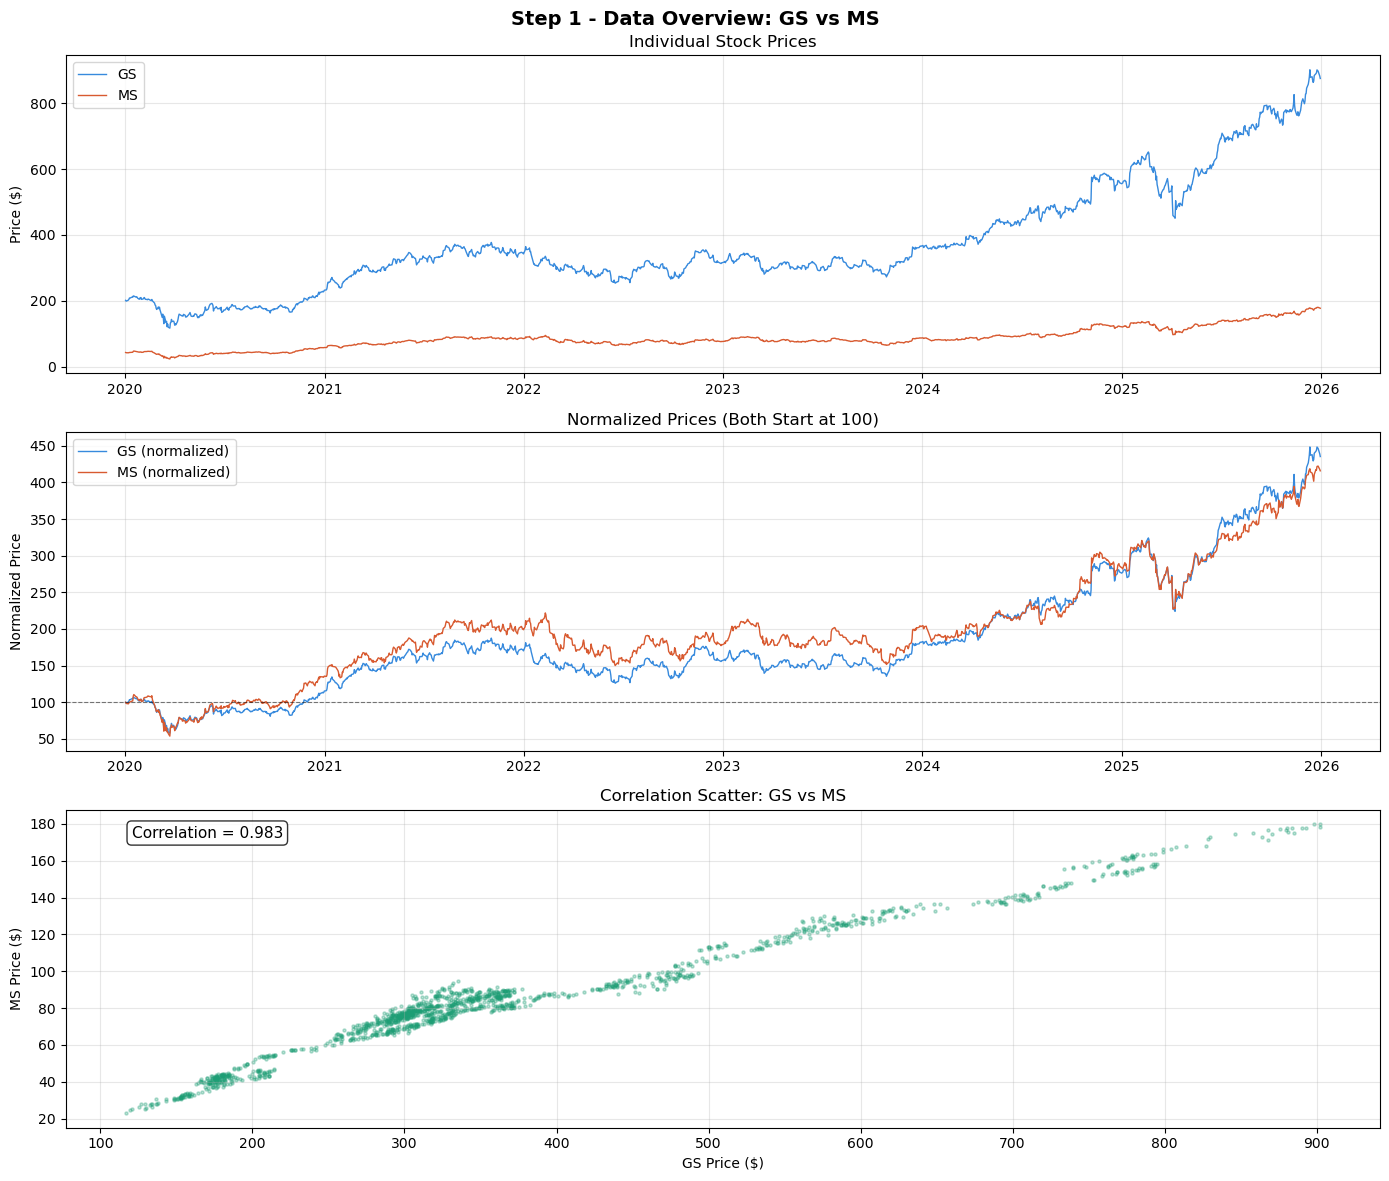

Chart saved as step1_data_overview.png


In [ ]:
# ═══════════════════════════════════════════════════════
# USER INPUTS — CHANGE THESE TO TEST DIFFERENT PAIRS
# ═══════════════════════════════════════════════════════

# Stock pair to analyze
TICKER1 = 'GS'        # First stock  e.g. 'GS', 'XOM', 'AAPL'
TICKER2 = 'MS'       # Second stock e.g. 'MS', 'CVX', 'MSFT'

# Date range
START_DATE = '2020-01-01'   # Format: YYYY-MM-DD
END_DATE   = '2025-12-31'   # Format: YYYY-MM-DD

# Strategy parameters
ENTRY_Z = 2.0   # Enter trade when z-score exceeds this
EXIT_Z  = 0.5   # Exit trade when z-score returns below this
STOP_Z  = 3.0   # Emergency exit if z-score exceeds this

# Capital
CAPITAL = 10000  # Starting capital in dollars
COST    = 5.0    # Transaction cost per trade in dollars

# ═══════════════════════════════════════════════════════
# SUGGESTED PAIRS TO TRY:
#
# TICKER1 = 'V'    TICKER2 = 'MA'    (payments)
# TICKER1 = 'KO'   TICKER2 = 'PEP'   (beverages)
# TICKER1 = 'GS'   TICKER2 = 'MS'    (banks)
# TICKER1 = 'XOM'  TICKER2 = 'CVX'   (oil)
# TICKER1 = 'WMT'  TICKER2 = 'TGT'   (retail)
# TICKER1 = 'JPM'  TICKER2 = 'BAC'   (banks)
# ═══════════════════════════════════════════════════════

print("=" * 55)
print("MEAN REVERSION STRATEGY - CONFIGURATION")
print("=" * 55)
print(f"Pair selected:       {TICKER1} vs {TICKER2}")
print(f"Date range:          {START_DATE} to {END_DATE}")
print(f"Entry threshold:     z = +/- {ENTRY_Z}")
print(f"Exit threshold:      z = +/- {EXIT_Z}")
print(f"Stop loss:           z = +/- {STOP_Z}")
print(f"Starting capital:    ${CAPITAL:,}")
print(f"Cost per trade:      ${COST}")
print("=" * 55)
print()
print("To test a different pair:")
print("  1. Change TICKER1 and TICKER2 above")
print("  2. Run ALL cells from top to bottom")
print("  3. Check the final verdict at the bottom")
print()

# ─────────────────────────────────────────
# DOWNLOAD DATA
# ─────────────────────────────────────────

print(f"Downloading {TICKER1} data...")
data1 = yf.download(TICKER1,
                     start=START_DATE,
                     end=END_DATE,
                     progress=False)

print(f"Downloading {TICKER2} data...")
data2 = yf.download(TICKER2,
                     start=START_DATE,
                     end=END_DATE,
                     progress=False)

# ─────────────────────────────────────────
# BUILD PRICES TABLE
# ─────────────────────────────────────────

prices = pd.DataFrame({
    TICKER1: data1['Close'].squeeze(),
    TICKER2: data2['Close'].squeeze()
}).dropna()

# ─────────────────────────────────────────
# PRINT DATA SUMMARY
# ─────────────────────────────────────────

print()
print("=" * 55)
print("DATA SUMMARY")
print("=" * 55)
print(f"Trading days loaded:  {len(prices)}")
print(f"Start date:           {prices.index[0].date()}")
print(f"End date:             {prices.index[-1].date()}")
print()
print(f"{TICKER1} price range:")
print(f"  Min: ${prices[TICKER1].min():.2f}")
print(f"  Max: ${prices[TICKER1].max():.2f}")
print(f"  Current: ${prices[TICKER1].iloc[-1]:.2f}")
print()
print(f"{TICKER2} price range:")
print(f"  Min: ${prices[TICKER2].min():.2f}")
print(f"  Max: ${prices[TICKER2].max():.2f}")
print(f"  Current: ${prices[TICKER2].iloc[-1]:.2f}")
print()
print("First 5 rows:")
print(prices.head())
print()
print("Data loaded successfully")

# ─────────────────────────────────────────
# VISUALIZE RAW DATA
# ─────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle(f'Step 1 - Data Overview: {TICKER1} vs {TICKER2}',
             fontsize=14, fontweight='bold')

# Plot 1 - Individual stock prices
axes[0].plot(prices.index, prices[TICKER1],
             color='#378ADD', lw=1.0,
             label=TICKER1)
axes[0].plot(prices.index, prices[TICKER2],
             color='#D85A30', lw=1.0,
             label=TICKER2)
axes[0].set_title('Individual Stock Prices')
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 - Normalized prices
# Both start at 100 so we can compare performance
norm1 = prices[TICKER1] / prices[TICKER1].iloc[0] * 100
norm2 = prices[TICKER2] / prices[TICKER2].iloc[0] * 100

axes[1].plot(prices.index, norm1,
             color='#378ADD', lw=1.0,
             label=f'{TICKER1} (normalized)')
axes[1].plot(prices.index, norm2,
             color='#D85A30', lw=1.0,
             label=f'{TICKER2} (normalized)')
axes[1].axhline(y=100,
                color='black', ls='--',
                lw=0.8, alpha=0.5)
axes[1].set_title('Normalized Prices (Both Start at 100)')
axes[1].set_ylabel('Normalized Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3 - Correlation scatter
axes[2].scatter(prices[TICKER1],
                prices[TICKER2],
                alpha=0.3,
                color='#1D9E75',
                s=5)
axes[2].set_title(f'Correlation Scatter: {TICKER1} vs {TICKER2}')
axes[2].set_xlabel(f'{TICKER1} Price ($)')
axes[2].set_ylabel(f'{TICKER2} Price ($)')
axes[2].grid(True, alpha=0.3)

corr_scatter = prices[TICKER1].corr(prices[TICKER2])
axes[2].text(0.05, 0.95,
             f'Correlation = {corr_scatter:.3f}',
             transform=axes[2].transAxes,
             fontsize=11,
             verticalalignment='top',
             bbox=dict(boxstyle='round',
                       facecolor='white',
                       alpha=0.8))

plt.tight_layout()
plt.savefig('step1_data_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved as step1_data_overview.png")

## Step 2 - Statistical Tests for Mean Reversion

Looking at a chart is not enough. We need **mathematical proof**
that mean reversion is real before risking any money.

We run five tests, each answering a different question:

---

### Test 1 — Correlation
*Are the two stocks actually linked?*

Measures the linear relationship between the two price series.
Must be above 0.7 for a valid pair.

---

### Test 2 — Lambda
*Does mean reversion exist and how strong is it?*

We estimate $\lambda$ from the **ADF regression**:

$$\Delta X_t = \alpha + \lambda X_{t-1} + \varepsilon_t$$

Where $\Delta X_t = X_t - X_{t-1}$ is today's change in spread
and $X_{t-1}$ is yesterday's spread level.

A **negative** $\lambda$ means: when the spread is high it tends
to fall, and when low it tends to rise — this is mean reversion.

$$\lambda < 0 \Rightarrow \text{Mean reversion exists}$$

---

### Test 3 — T-Statistic
*Is lambda real or just random luck?*

Even if lambda looks negative it could be a coincidence.
The t-statistic tests this:

$$t = \frac{\hat{\lambda}}{SE(\hat{\lambda})}$$

Must exceed 2.0 in absolute value for 95% confidence.

$$|t| > 2.0 \Rightarrow \lambda \text{ is statistically significant}$$

---

### Test 4 — Half Life
*How fast does the spread revert?*

The half life tells us how many days it takes for half
of a deviation from the mean to disappear:

$$\text{Half Life} = \frac{\ln(2)}{|\lambda|}$$

Must be below 30 days for the strategy to overcome transaction costs.

---

### Test 5 — Augmented Dickey Fuller Test
*Is the spread stationary?*

The ADF test is the formal statistical proof of stationarity.
It tests the null hypothesis that the spread is a random walk
with no tendency to revert.

$$H_0: \lambda = 0 \quad \text{(random walk — no mean reversion)}$$
$$H_1: \lambda < 0 \quad \text{(stationary — mean reversion exists)}$$

A p-value below 0.05 rejects the null hypothesis and confirms
mean reversion at the 95% confidence level.

---

**All five tests must pass before proceeding to model building.**
If any critical test fails we should find a different pair.

STATISTICAL TESTS FOR MEAN REVERSION
Pair: GS vs MS

Spread type:    Normalized price spread
Spread mean:    -63.3420
Spread std:     30.4598
Spread min:     -151.9544
Spread max:     4.7361

TEST 1 - CORRELATION
----------------------------------------
Correlation: 0.9828
PASS - Strong correlation (above 0.8)

TEST 2 - LAMBDA (Mean Reversion Strength)
----------------------------------------
Lambda: -0.0109
WEAK PASS - Weak but present

TEST 3 - T-STATISTIC (Is Lambda Significant?)
----------------------------------------
T-statistic: -2.9316
P-value:     0.003423
PASS - Lambda is statistically significant

TEST 4 - HALF LIFE (Speed of Reversion)
----------------------------------------
Half life: 63.8 days
FAIL - Too slow to trade profitably

TEST 5 - ADF TEST (Is Spread Stationary?)
----------------------------------------
ADF Statistic: -2.7685
P-value:       0.062912
FAIL - Not stationary (p above 0.05)

OVERALL SCORE: 3/5
PASS - Some evidence, proceed with caution


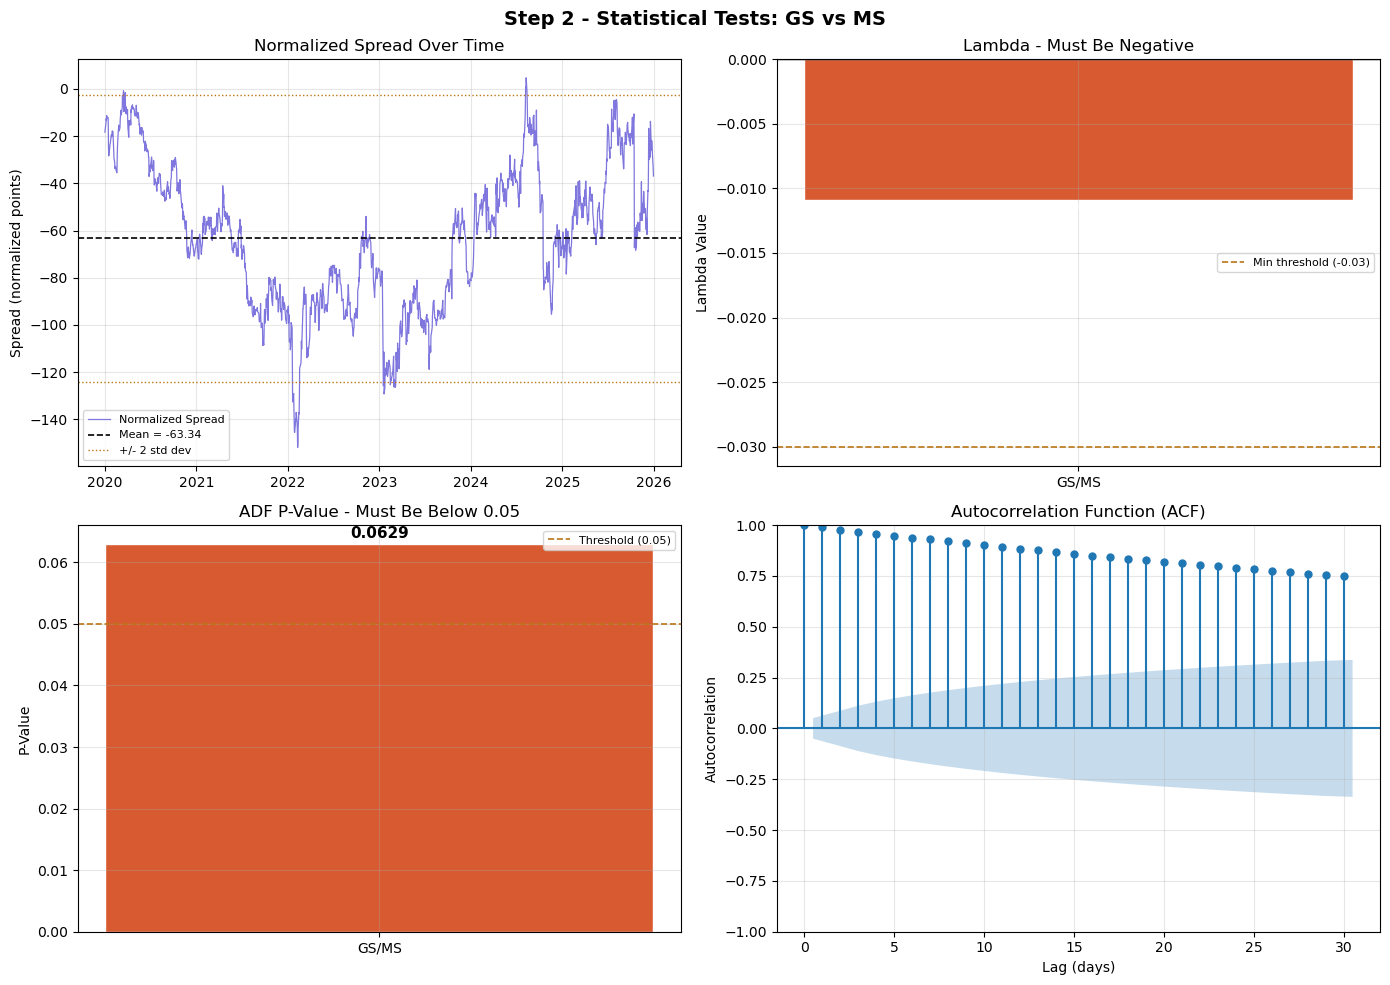

Chart saved as step2_statistical_tests.png


In [ ]:
# ─────────────────────────────────────────
# STEP 1 - BUILD NORMALIZED SPREAD
# ─────────────────────────────────────────

# Normalize both stocks to start at 100
norm1 = prices[TICKER1] / prices[TICKER1].iloc[0] * 100
norm2 = prices[TICKER2] / prices[TICKER2].iloc[0] * 100

# Spread = difference in normalized performance
# Run OLS to find hedge ratio
from statsmodels.regression.linear_model import OLS

spread = (norm1-norm2).values
spread_series = pd.Series(spread, index=prices.index)
n             = len(spread)
mu            = np.mean(spread)
sigma         = np.std(spread)

print("=" * 55)
print("STATISTICAL TESTS FOR MEAN REVERSION")
print(f"Pair: {TICKER1} vs {TICKER2}")
print("=" * 55)
print(f"\nSpread type:    Normalized price spread")
print(f"Spread mean:    {mu:.4f}")
print(f"Spread std:     {sigma:.4f}")
print(f"Spread min:     {spread.min():.4f}")
print(f"Spread max:     {spread.max():.4f}")

# ─────────────────────────────────────────
# TEST 1 - CORRELATION
# ─────────────────────────────────────────

corr = prices[TICKER1].corr(prices[TICKER2])

print(f"\nTEST 1 - CORRELATION")
print(f"-" * 40)
print(f"Correlation: {corr:.4f}")

if corr > 0.8:
    print(f"PASS - Strong correlation (above 0.8)")
    corr_pass = True
elif corr > 0.6:
    print(f"WEAK - Moderate correlation (0.6 to 0.8)")
    corr_pass = True
else:
    print(f"FAIL - Weak correlation (below 0.6)")
    corr_pass = False

# ─────────────────────────────────────────
# TEST 2 - LAMBDA
# ─────────────────────────────────────────

# Correct ADF regression
# delta(spread) = lambda * spread[t-1] + error
# Negative lambda = mean reversion exists

# This gives us the beta coefficient
# which is our lambda

# ADF regression
# ΔXₜ = α + β × Xₜ₋₁ + εₜ
# β is our lambda

delta_sp = np.diff(spread)    # ΔXₜ = today - yesterday
sp_lag   = spread[:-1]        # Xₜ₋₁ = yesterday's level

X        = sm.add_constant(sp_lag)
model    = sm.OLS(delta_sp, X).fit()
lambda_  = model.params.iloc[1]    # β coefficient
t_stat   = model.tvalues.iloc[1]   # t-statistic from regression
p_value  = model.pvalues.iloc[1]   # p-value from regression

print(f"\nTEST 2 - LAMBDA (Mean Reversion Strength)")
print(f"-" * 40)
print(f"Lambda: {lambda_:.4f}")

if lambda_ < -0.1:
    print(f"PASS - Strong mean reversion")
    lambda_pass = True
elif lambda_ < -0.03:
    print(f"PASS - Moderate mean reversion")
    lambda_pass = True
elif lambda_ < -0.01:
    print(f"WEAK PASS - Weak but present")
    lambda_pass = True
elif lambda_ < 0:
    print(f"WEAK - Very weak mean reversion")
    lambda_pass = False
else:
    print(f"FAIL - No mean reversion (momentum)")
    lambda_pass = False

# ─────────────────────────────────────────
# TEST 3 - T STATISTIC
# ─────────────────────────────────────────

# T-statistic comes directly from
# the OLS regression above
# No need to recalculate manually

print(f"\nTEST 3 - T-STATISTIC (Is Lambda Significant?)")
print(f"-" * 40)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.6f}")

if abs(t_stat) > 2.0:
    print(f"PASS - Lambda is statistically significant")
    tstat_pass = True
else:
    print(f"FAIL - Lambda could be random noise")
    tstat_pass = False


# ─────────────────────────────────────────
# TEST 4 - HALF LIFE
# ─────────────────────────────────────────

if lambda_ < 0:
    half_life = np.log(2) /abs(lambda_)
else:
    half_life = 999

print(f"\nTEST 4 - HALF LIFE (Speed of Reversion)")
print(f"-" * 40)
print(f"Half life: {half_life:.1f} days")

if half_life < 10:
    print(f"PASS - Very fast reversion")
    hl_pass = True
elif half_life < 30:
    print(f"PASS - Fast enough to trade profitably")
    hl_pass = True
elif half_life < 60:
    print(f"WEAK PASS - Slow but borderline tradeable")
    hl_pass = True
else:
    print(f"FAIL - Too slow to trade profitably")
    hl_pass = False

# ─────────────────────────────────────────
# TEST 5 - ADF TEST
# ─────────────────────────────────────────

adf_result = adfuller(spread)
adf_stat   = adf_result[0]
adf_pvalue = adf_result[1]

print(f"\nTEST 5 - ADF TEST (Is Spread Stationary?)")
print(f"-" * 40)
print(f"ADF Statistic: {adf_stat:.4f}")
print(f"P-value:       {adf_pvalue:.6f}")

if adf_pvalue < 0.01:
    print(f"STRONG PASS - Highly stationary (p below 0.01)")
    adf_pass = True
elif adf_pvalue < 0.05:
    print(f"PASS - Stationary (p below 0.05)")
    adf_pass = True
else:
    print(f"FAIL - Not stationary (p above 0.05)")
    adf_pass = False

# ─────────────────────────────────────────
# OVERALL SCORE
# ─────────────────────────────────────────

score = sum([corr_pass, lambda_pass,
             tstat_pass, hl_pass, adf_pass])
total = 5

print(f"\n{'=' * 55}")
print(f"OVERALL SCORE: {score}/{total}")
print(f"{'=' * 55}")

if score >= 4:
    print(f"STRONG PASS - Proceed to model building")
elif score >= 3:
    print(f"PASS - Some evidence, proceed with caution")
else:
    print(f"FAIL - Consider a different pair")

# Store everything for later cells
test_results = {
    'correlation': corr,
    'lambda':      lambda_,
    't_stat':      t_stat,
    'p_value':     p_value,
    'half_life':   half_life,
    'adf_pvalue':  adf_pvalue,
    'adf_stat':    adf_stat,
    'score':       score,
    'mu':          mu,
    'sigma':       sigma,
    'spread':      spread,
    'spread_series': spread_series,
    'norm1':       norm1,
    'norm2':       norm2
}

# ─────────────────────────────────────────
# VISUALIZE
# ─────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Step 2 - Statistical Tests: {TICKER1} vs {TICKER2}',
             fontsize=14, fontweight='bold')

# Plot 1 - Spread over time
axes[0, 0].plot(spread_series.index,
                spread_series.values,
                color='#7F77DD', lw=0.9,
                label='Normalized Spread')
axes[0, 0].axhline(y=mu,
                    color='black', ls='--', lw=1.2,
                    label=f'Mean = {mu:.2f}')
axes[0, 0].axhline(y=mu + 2*sigma,
                    color='#BA7517', ls=':', lw=1.0,
                    label='+/- 2 std dev')
axes[0, 0].axhline(y=mu - 2*sigma,
                    color='#BA7517', ls=':', lw=1.0)
axes[0, 0].set_title('Normalized Spread Over Time')
axes[0, 0].set_ylabel('Spread (normalized points)')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2 - Lambda bar
labels     = [f'{TICKER1}/{TICKER2}']
bar_colors = ['#1D9E75' if lambda_ < -0.03 else '#D85A30']

axes[0, 1].bar(labels, [lambda_],
               color=bar_colors,
               width=0.3,
               edgecolor='white')
axes[0, 1].axhline(y=0,
                    color='black', lw=1.0)
axes[0, 1].axhline(y=-0.03,
                    color='#BA7517', lw=1.2,
                    ls='--',
                    label='Min threshold (-0.03)')
axes[0, 1].set_title('Lambda - Must Be Negative')
axes[0, 1].set_ylabel('Lambda Value')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].text(0, lambda_ - 0.001,
                f'{lambda_:.4f}',
                ha='center',
                fontsize=11,
                fontweight='bold',
                color='white')

# Plot 3 - ADF p-value
adf_color = '#1D9E75' if adf_pvalue < 0.05 else '#D85A30'
axes[1, 0].bar(labels, [adf_pvalue],
               color=adf_color,
               width=0.3,
               edgecolor='white')
axes[1, 0].axhline(y=0.05,
                    color='#BA7517', lw=1.2,
                    ls='--',
                    label='Threshold (0.05)')
axes[1, 0].set_title('ADF P-Value - Must Be Below 0.05')
axes[1, 0].set_ylabel('P-Value')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].text(0, adf_pvalue + 0.001,
                f'{adf_pvalue:.4f}',
                ha='center',
                fontsize=11,
                fontweight='bold')

# Plot 4 - Autocorrelation
plot_acf(spread_series, lags=30,
         ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('Autocorrelation Function (ACF)')
axes[1, 1].set_xlabel('Lag (days)')
axes[1, 1].set_ylabel('Autocorrelation')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step2_statistical_tests.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved as step2_statistical_tests.png")

## Step 3 - Building the AR(1) Model

Having confirmed that mean reversion exists we now **quantify exactly
how it works** by estimating the parameters of our AR(1) model.

### The Model

$$r_t = \mu + \lambda(r_{t-1} - \mu) + \sigma z_t$$

### Train Test Split

We split the data into two parts to ensure honest evaluation:

$$\text{Training set (70\%)} \rightarrow \text{estimate } \mu, \sigma, \lambda$$
$$\text{Test set (30\%)} \rightarrow \text{honest out-of-sample evaluation}$$

We **never touch the test data** during model building.
This is identical to how real quantitative funds validate strategies —
using historical data to build the model and fresh data to test it.

### Rolling Lambda

We also calculate lambda on a rolling 60-day window:

$$\lambda_t = \frac{\sum_{i=t-60}^{t} \Delta X_i \cdot X_{i-1}}{\sum_{i=t-60}^{t} X_{i-1}^2}$$

This answers: **is mean reversion stable over time or does it
come and go?** If lambda stays negative more than 80% of the time
the strategy is reliable.

### Model Quality — Residuals

After estimating parameters we check the residuals:

$$\varepsilon_t = r_t - [\mu + \lambda(r_{t-1} - \mu)]$$

Good residuals should:
- Have mean near zero: $E[\varepsilon_t] \approx 0$
- Look like a bell curve (normally distributed)
- Have standard deviation close to $\sigma$

If residuals are well behaved the AR(1) model is a good
description of how the spread actually moves.

### 1000 Simulated Paths

Using our estimated parameters we simulate 1000 possible futures:

$$r_t^{(k)} = \mu + \lambda(r_{t-1}^{(k)} - \mu) + \sigma z_t^{(k)}, \quad k = 1,...,1000$$

Each path uses different random shocks $z_t^{(k)}$ but the same
parameters. This gives us a picture of the full range of possible
outcomes before committing any capital.

AR(1) MODEL - PARAMETER ESTIMATION
Pair: GS vs MS

DATA SPLIT:
Total days:     1507
Training days:  1054
  From: 2020-01-02
  To:   2024-03-11
Test days:      453
  From: 2024-03-12
  To:   2025-12-30

MODEL PARAMETERS (from training data):
----------------------------------------
Mean       (mu):      -20.9410
Std Dev    (sigma):   12.0482
Lambda     (lambda):  -0.0114
Half life:            61.0 days
Expected P/L:         1.6501 per unit

YOUR AR(1) MODEL:
rt = -20.9410 + (-0.0114) x (rt-1 - -20.9410) + 12.0482 x zt

MODEL FIT QUALITY:
----------------------------------------
Residual mean:  -0.020025
              (should be near zero)
Residual std:   12.1721
              (should be near sigma)
Max residual:   34.7453

ROLLING LAMBDA ANALYSIS (60 day window):
----------------------------------------
Average rolling lambda:  -0.1047
Current rolling lambda:  -0.1066
Std dev of lambda:       0.0782
Min lambda:              -0.4223
Max lambda:              0.0932
% time lambda negative:

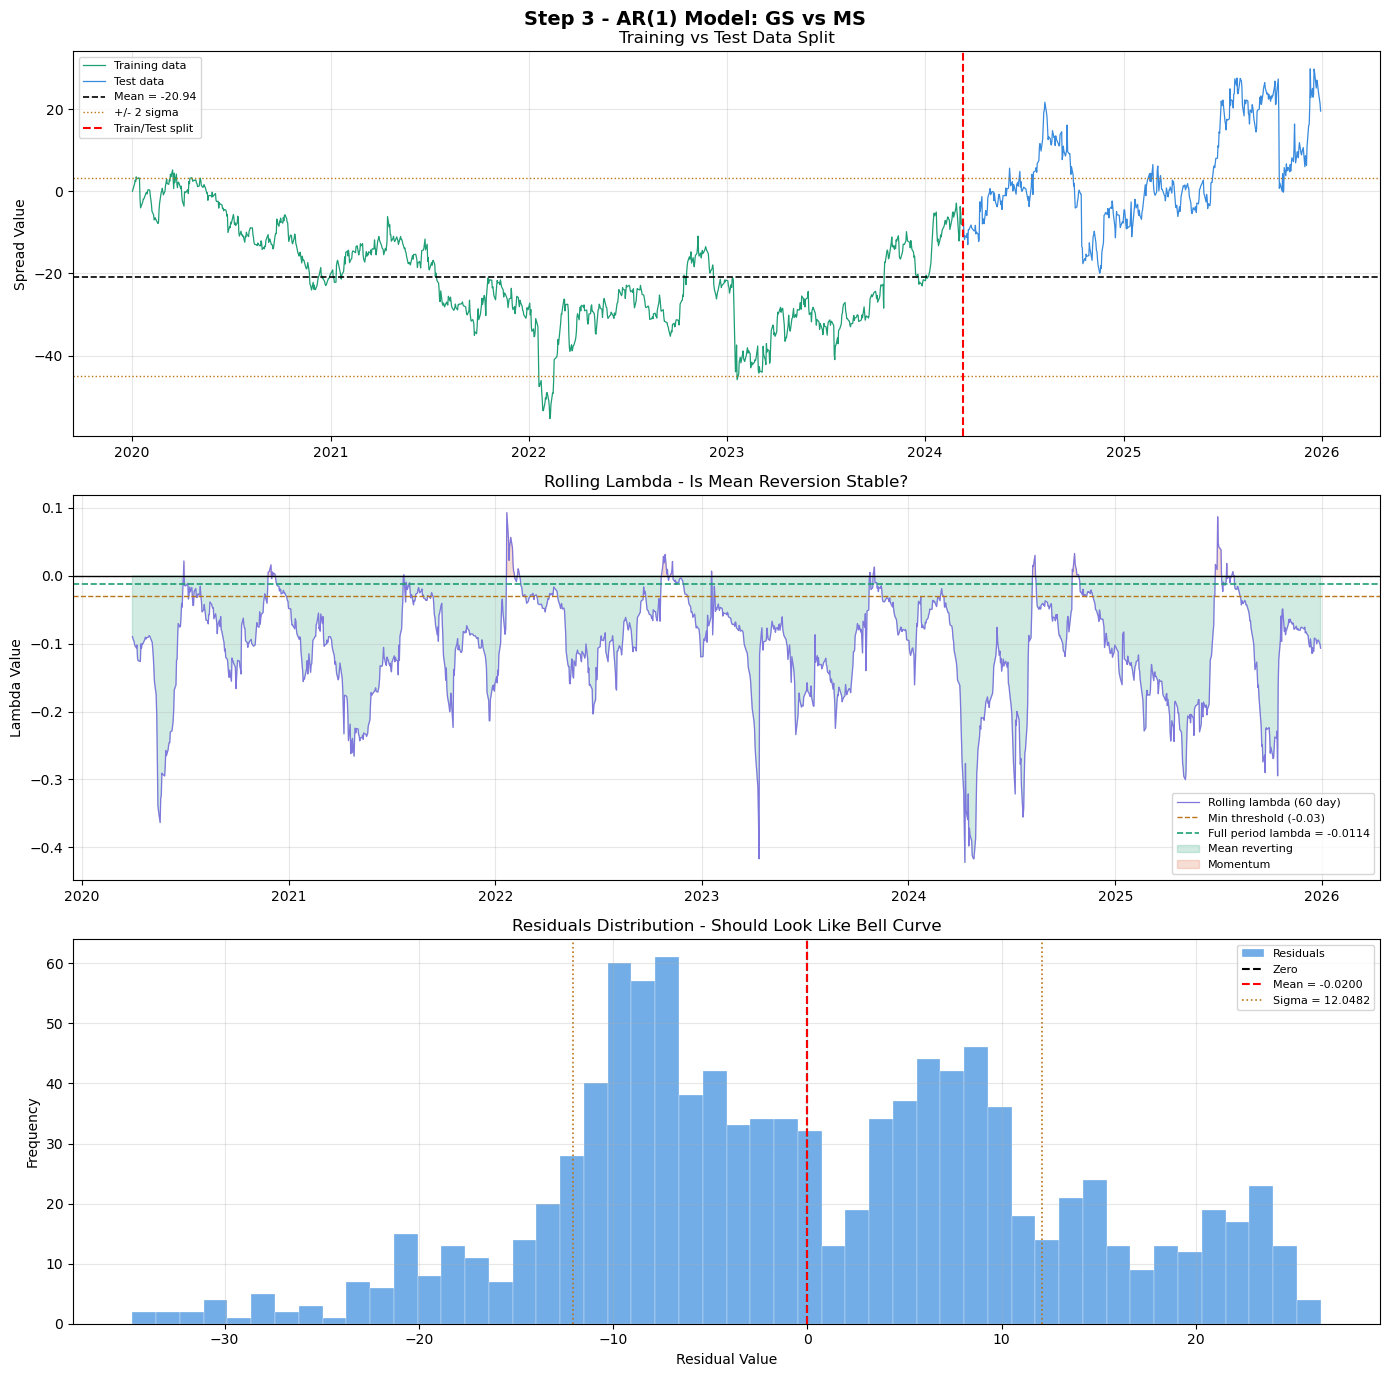

Chart saved as step3_ar1_model.png

1000 SIMULATED PATHS OF AR(1) MODEL
Number of paths:        1000
Days per path:          453
Average final value:    -20.5113
Std of final values:    12.2606
Min final value:        -62.8460
Max final value:        20.9309
% paths above mu:       52.7%
% paths below mu:       47.3%


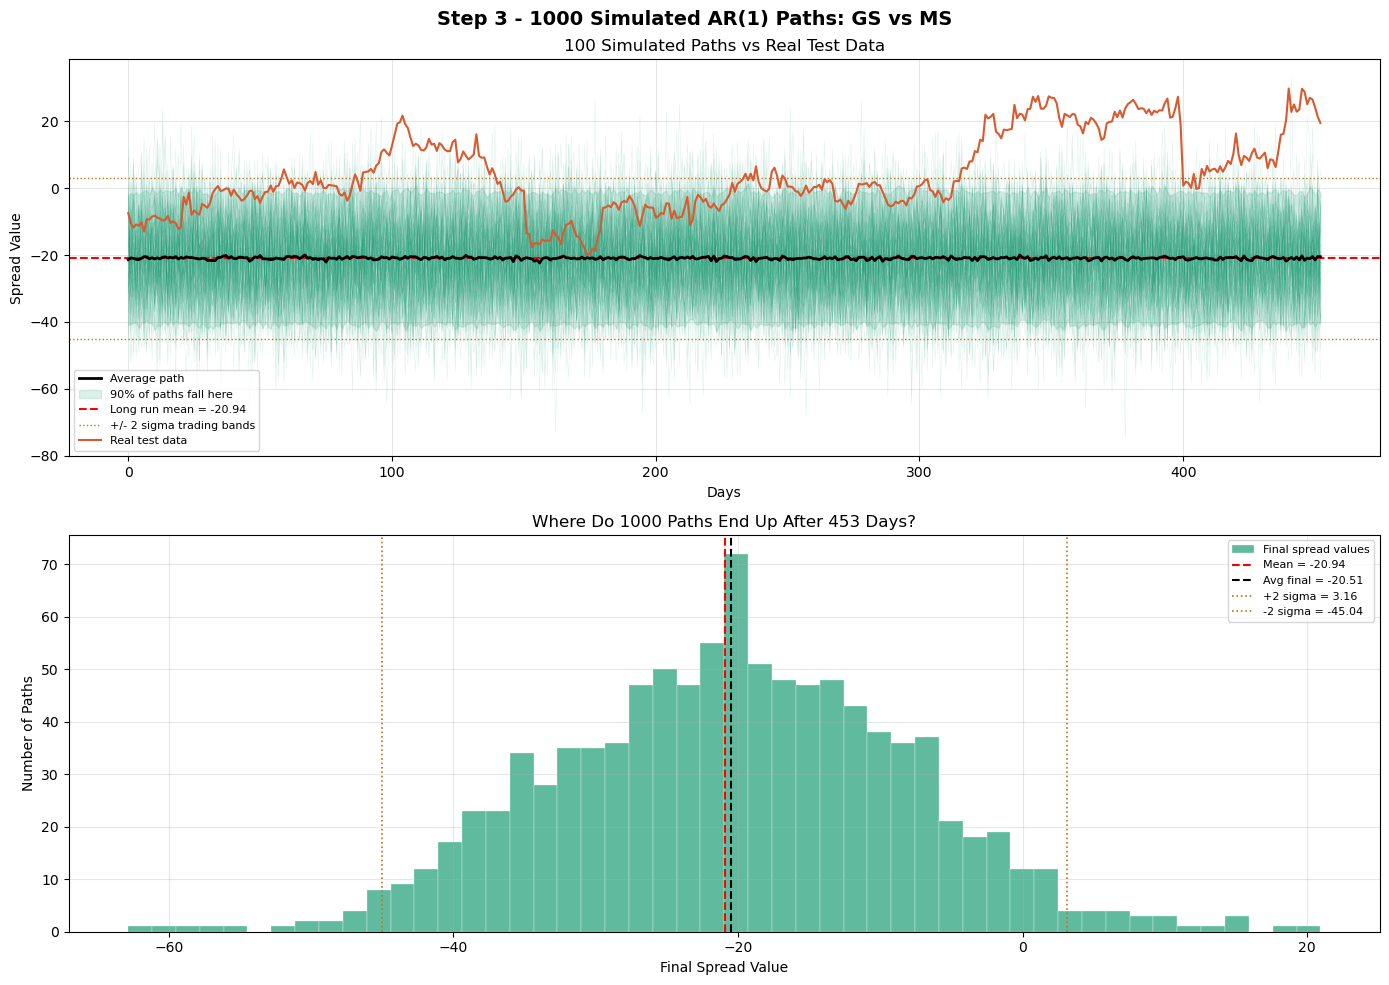

Saved: step3_1000_paths.png


In [ ]:
# ─────────────────────────────────────────
# STEP 1 - SPLIT DATA INTO TRAIN AND TEST
# ─────────────────────────────────────────

split       = int(len(spread) * 0.7)

train       = spread[:split]
test        = spread[split:]

dates_all   = spread_series.index
dates_train = dates_all[:split]
dates_test  = dates_all[split:]

print("=" * 55)
print("AR(1) MODEL - PARAMETER ESTIMATION")
print(f"Pair: {TICKER1} vs {TICKER2}")
print("=" * 55)

print(f"\nDATA SPLIT:")
print(f"Total days:     {len(spread)}")
print(f"Training days:  {len(train)}")
print(f"  From: {dates_train[0].date()}")
print(f"  To:   {dates_train[-1].date()}")
print(f"Test days:      {len(test)}")
print(f"  From: {dates_test[0].date()}")
print(f"  To:   {dates_test[-1].date()}")

# ─────────────────────────────────────────
# STEP 2 - ESTIMATE PARAMETERS ON TRAIN
# ─────────────────────────────────────────

# Mean
mu_train    = np.mean(train)

# Standard deviation
sigma_train = np.std(train)

# Lambda using ADF regression
# delta(spread) = lambda * spread[t-1] + error
delta_train = np.diff(train)
lag_train   = train[:-1]

X_train     = sm.add_constant(lag_train)
ar_train    = sm.OLS(delta_train, X_train).fit()
lambda_train = ar_train.params[1]

# Half life
if lambda_train < 0:
    hl_train = np.log(2) / abs(lambda_train)
else:
    hl_train = 999

# Expected daily P/L
gamma_0     = sigma_train**2 / (1 - lambda_train**2) \
              if abs(lambda_train) < 1 else sigma_train**2
exp_pnl     = abs(lambda_train) * gamma_0

print(f"\nMODEL PARAMETERS (from training data):")
print(f"-" * 40)
print(f"Mean       (mu):      {mu_train:.4f}")
print(f"Std Dev    (sigma):   {sigma_train:.4f}")
print(f"Lambda     (lambda):  {lambda_train:.4f}")
print(f"Half life:            {hl_train:.1f} days")
print(f"Expected P/L:         {exp_pnl:.4f} per unit")

print(f"\nYOUR AR(1) MODEL:")
print(f"rt = {mu_train:.4f} + "
      f"({lambda_train:.4f}) x (rt-1 - {mu_train:.4f})"
      f" + {sigma_train:.4f} x zt")

# ─────────────────────────────────────────
# STEP 3 - MODEL PREDICTIONS ON TRAIN
# ─────────────────────────────────────────

# Predict each day using yesterday's real value
predicted    = np.zeros(len(train))
predicted[0] = mu_train

for t in range(1, len(train)):
    predicted[t] = mu_train + lambda_train * \
                   (train[t-1] - mu_train)

# Residuals
residuals = train[1:] - predicted[1:]

print(f"\nMODEL FIT QUALITY:")
print(f"-" * 40)
print(f"Residual mean:  {np.mean(residuals):.6f}")
print(f"              (should be near zero)")
print(f"Residual std:   {np.std(residuals):.4f}")
print(f"              (should be near sigma)")
print(f"Max residual:   {np.max(np.abs(residuals)):.4f}")

# ─────────────────────────────────────────
# STEP 4 - ROLLING LAMBDA
# ─────────────────────────────────────────

window          = 60
rolling_lambdas = []
rolling_dates   = []
rolling_hls     = []

for i in range(window, len(spread)):
    w_data    = spread[i-window:i]
    w_delta   = np.diff(w_data)
    w_lag     = w_data[:-1]

    X_w       = sm.add_constant(w_lag)
    ar_w      = sm.OLS(w_delta, X_w).fit()
    lam_w     = ar_w.params[1]

    hl_w      = np.log(2) / abs(lam_w) \
                if lam_w < 0 else 999

    rolling_lambdas.append(lam_w)
    rolling_hls.append(hl_w)
    rolling_dates.append(dates_all[i])

rolling_lambdas = np.array(rolling_lambdas)
rolling_hls     = np.array(rolling_hls)

pct_negative    = np.mean(rolling_lambdas < 0) * 100
current_lambda  = rolling_lambdas[-1]

print(f"\nROLLING LAMBDA ANALYSIS (60 day window):")
print(f"-" * 40)
print(f"Average rolling lambda:  {np.mean(rolling_lambdas):.4f}")
print(f"Current rolling lambda:  {current_lambda:.4f}")
print(f"Std dev of lambda:       {np.std(rolling_lambdas):.4f}")
print(f"Min lambda:              {np.min(rolling_lambdas):.4f}")
print(f"Max lambda:              {np.max(rolling_lambdas):.4f}")
print(f"% time lambda negative:  {pct_negative:.1f}%")

print(f"\nSTABILITY VERDICT:")
if pct_negative > 80:
    print(f"STABLE - Lambda negative {pct_negative:.1f}% of time")
    print(f"Safe to trade")
elif pct_negative > 60:
    print(f"MODERATE - Lambda negative {pct_negative:.1f}% of time")
    print(f"Trade with reduced size")
else:
    print(f"UNSTABLE - Lambda negative only {pct_negative:.1f}% of time")
    print(f"Consider different pair")

print(f"\nCURRENT SIGNAL:")
if current_lambda < -0.03:
    print(f"ACTIVE - Mean reversion currently present")
    print(f"Strategy is ON")
elif current_lambda < 0:
    print(f"WEAK - Very weak mean reversion currently")
    print(f"Reduce position size")
else:
    print(f"INACTIVE - No mean reversion currently")
    print(f"Strategy is OFF")

# Store parameters for later cells
model_params = {
    'mu':           mu_train,
    'sigma':        sigma_train,
    'lambda':       lambda_train,
    'half_life':    hl_train,
    'train':        train,
    'test':         test,
    'dates_train':  dates_train,
    'dates_test':   dates_test,
    'predicted':    predicted,
    'residuals':    residuals,
    'rolling_lambdas': rolling_lambdas,
    'rolling_dates':   rolling_dates,
    'rolling_hls':     rolling_hls,
    'split':        split
}

# ─────────────────────────────────────────
# VISUALIZE
# ─────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle(f'Step 3 - AR(1) Model: {TICKER1} vs {TICKER2}',
             fontsize=14, fontweight='bold')

# Plot 1 - Train test split with bands
axes[0].plot(dates_train,
             train,
             color='#1D9E75', lw=0.9,
             label='Training data')
axes[0].plot(dates_test,
             test,
             color='#378ADD', lw=0.9,
             label='Test data')
axes[0].axhline(y=mu_train,
                color='black', ls='--', lw=1.2,
                label=f'Mean = {mu_train:.2f}')
axes[0].axhline(y=mu_train + 2*sigma_train,
                color='#BA7517', ls=':', lw=1.0,
                label='+/- 2 sigma')
axes[0].axhline(y=mu_train - 2*sigma_train,
                color='#BA7517', ls=':', lw=1.0)
axes[0].axvline(x=dates_all[split],
                color='red', ls='--', lw=1.5,
                label='Train/Test split')
axes[0].set_title('Training vs Test Data Split')
axes[0].set_ylabel('Spread Value')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot 2 - Rolling lambda
axes[1].plot(rolling_dates,
             rolling_lambdas,
             color='#7F77DD', lw=0.9,
             label='Rolling lambda (60 day)')
axes[1].axhline(y=0,
                color='black', ls='-', lw=1.0)
axes[1].axhline(y=-0.03,
                color='#BA7517', ls='--', lw=1.0,
                label='Min threshold (-0.03)')
axes[1].axhline(y=lambda_train,
                color='#1D9E75', ls='--', lw=1.2,
                label=f'Full period lambda = {lambda_train:.4f}')
axes[1].fill_between(rolling_dates,
                      rolling_lambdas, 0,
                      where=(rolling_lambdas < 0),
                      alpha=0.2, color='#1D9E75',
                      label='Mean reverting')
axes[1].fill_between(rolling_dates,
                      rolling_lambdas, 0,
                      where=(rolling_lambdas >= 0),
                      alpha=0.2, color='#D85A30',
                      label='Momentum')
axes[1].set_title('Rolling Lambda - Is Mean Reversion Stable?')
axes[1].set_ylabel('Lambda Value')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Plot 3 - Residuals distribution
axes[2].hist(residuals,
             bins=50,
             color='#378ADD',
             alpha=0.7,
             edgecolor='white',
             lw=0.3,
             label='Residuals')
axes[2].axvline(x=0,
                color='black', ls='--', lw=1.5,
                label='Zero')
axes[2].axvline(x=np.mean(residuals),
                color='red', ls='--', lw=1.5,
                label=f'Mean = {np.mean(residuals):.4f}')
axes[2].axvline(x=sigma_train,
                color='#BA7517', ls=':', lw=1.2,
                label=f'Sigma = {sigma_train:.4f}')
axes[2].axvline(x=-sigma_train,
                color='#BA7517', ls=':', lw=1.2)
axes[2].set_title('Residuals Distribution - Should Look Like Bell Curve')
axes[2].set_xlabel('Residual Value')
axes[2].set_ylabel('Frequency')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step3_ar1_model.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved as step3_ar1_model.png")
# ─────────────────────────────────────────
# SIMULATE 1000 PATHS OF AR(1) MODEL
# ─────────────────────────────────────────

n_paths  = 1000
n_days   = len(test)
np.random.seed(42)

all_paths = np.zeros((n_paths, n_days))

for path in range(n_paths):
    current = mu_train
    for day in range(n_days):
        z         = np.random.normal(0, 1)
        next_val  = mu_train + lambda_train * \
                    (current - mu_train) + sigma_train * z
        all_paths[path, day] = next_val
        current   = next_val

# ─────────────────────────────────────────
# SUMMARY STATISTICS
# ─────────────────────────────────────────

mean_path  = np.mean(all_paths, axis=0)
upper_95   = np.percentile(all_paths, 95, axis=0)
lower_5    = np.percentile(all_paths,  5, axis=0)
final_vals = all_paths[:, -1]

print()
print("=" * 55)
print("1000 SIMULATED PATHS OF AR(1) MODEL")
print("=" * 55)
print(f"Number of paths:        {n_paths}")
print(f"Days per path:          {n_days}")
print(f"Average final value:    {np.mean(final_vals):.4f}")
print(f"Std of final values:    {np.std(final_vals):.4f}")
print(f"Min final value:        {np.min(final_vals):.4f}")
print(f"Max final value:        {np.max(final_vals):.4f}")
print(f"% paths above mu:       {np.mean(final_vals > mu_train)*100:.1f}%")
print(f"% paths below mu:       {np.mean(final_vals < mu_train)*100:.1f}%")

# ─────────────────────────────────────────
# VISUALIZE PATHS
# ─────────────────────────────────────────

fig2, axes2 = plt.subplots(2, 1, figsize=(14, 10))
fig2.suptitle(f'Step 3 - 1000 Simulated AR(1) Paths: '
              f'{TICKER1} vs {TICKER2}',
              fontsize=14, fontweight='bold')

# Plot 1 - All paths
for path in range(100):
    axes2[0].plot(all_paths[path],
                  color='#1D9E75',
                  lw=0.3,
                  alpha=0.15)

# Average path
axes2[0].plot(mean_path,
              color='black',
              lw=2.0,
              label=f'Average path',
              zorder=5)

# 90% confidence band
axes2[0].fill_between(range(n_days),
                       lower_5,
                       upper_95,
                       alpha=0.15,
                       color='#1D9E75',
                       label='90% of paths fall here')

# Mean line
axes2[0].axhline(y=mu_train,
                  color='red',
                  ls='--', lw=1.5,
                  label=f'Long run mean = {mu_train:.2f}')

# 2 sigma bands
axes2[0].axhline(y=mu_train + 2*sigma_train,
                  color='#BA7517',
                  ls=':', lw=1.0,
                  label='+/- 2 sigma trading bands')
axes2[0].axhline(y=mu_train - 2*sigma_train,
                  color='#BA7517',
                  ls=':', lw=1.0)

# Real test data overlay
axes2[0].plot(test,
              color='#D85A30',
              lw=1.5,
              label='Real test data',
              zorder=6)

axes2[0].set_title('100 Simulated Paths vs Real Test Data')
axes2[0].set_ylabel('Spread Value')
axes2[0].set_xlabel('Days')
axes2[0].legend(fontsize=8)
axes2[0].grid(True, alpha=0.3)

# Plot 2 - Distribution of final values
axes2[1].hist(final_vals,
              bins=50,
              color='#1D9E75',
              alpha=0.7,
              edgecolor='white',
              lw=0.3,
              label='Final spread values')
axes2[1].axvline(x=mu_train,
                  color='red',
                  ls='--', lw=1.5,
                  label=f'Mean = {mu_train:.2f}')
axes2[1].axvline(x=np.mean(final_vals),
                  color='black',
                  ls='--', lw=1.5,
                  label=f'Avg final = {np.mean(final_vals):.2f}')
axes2[1].axvline(x=mu_train + 2*sigma_train,
                  color='#BA7517',
                  ls=':', lw=1.2,
                  label=f'+2 sigma = {mu_train+2*sigma_train:.2f}')
axes2[1].axvline(x=mu_train - 2*sigma_train,
                  color='#BA7517',
                  ls=':', lw=1.2,
                  label=f'-2 sigma = {mu_train-2*sigma_train:.2f}')

axes2[1].set_title(f'Where Do 1000 Paths End Up After {n_days} Days?')
axes2[1].set_xlabel('Final Spread Value')
axes2[1].set_ylabel('Number of Paths')
axes2[1].legend(fontsize=8)
axes2[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step3_1000_paths.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: step3_1000_paths.png")

# Store paths for later cells
model_params['all_paths']  = all_paths
model_params['mean_path']  = mean_path
model_params['final_vals'] = final_vals

## Step 4 - Kalman Filter

Even with a good model our observations contain noise.
Small random fluctuations in daily prices can trigger false
trading signals — entering positions that are not based on
genuine mean reversion but just random daily price movements.

The **Kalman filter** solves this by optimally combining two
imperfect sources of information:

$$\hat{X}_t = \hat{X}_{t-1}^{pred} + K_t(X_t^{obs} - \hat{X}_{t-1}^{pred})$$

Where:
- $\hat{X}_{t-1}^{pred}$ = what our AR(1) model predicted
- $X_t^{obs}$ = what we actually observed in the market
- $K_t$ = the **Kalman gain** — how much to trust each source

### The Kalman Gain

$$K_t = \frac{P_t^{pred}}{P_t^{pred} + R}$$

Where $P_t^{pred}$ is the model uncertainty and $R$ is the
observation noise. The filter automatically:

- Trusts the **observation more** when the model is uncertain
- Trusts the **model more** when observations are noisy

### Why This Improves Trading

| Without Kalman Filter | With Kalman Filter |
|----------------------|-------------------|
| Raw noisy spread | Smoothed spread estimate |
| Many false signals | Fewer higher quality signals |
| Higher transaction costs | Lower transaction costs |
| Noisier z-score | Cleaner z-score |

We run the backtest twice — once with raw z-scores and once
with Kalman filtered z-scores — and compare performance directly.

KALMAN FILTER RESULTS
Pair: GS vs MS

RAW SPREAD:
  Mean:           -63.3420
  Std dev:        30.4598
  Max z-score:    10.8741

KALMAN FILTERED SPREAD:
  Mean:           -62.4717
  Std dev:        30.0409
  Max z-score:    10.7009

AVERAGE KALMAN GAIN: 0.9858
  (0 = trust model, 1 = trust observation)

SIGNAL COMPARISON:
  Raw z-score signals:    1078
  Kalman z-score signals: 1065
  Signal reduction:       13 fewer signals

Kalman filter reduced noise signals
Fewer but higher quality trades expected


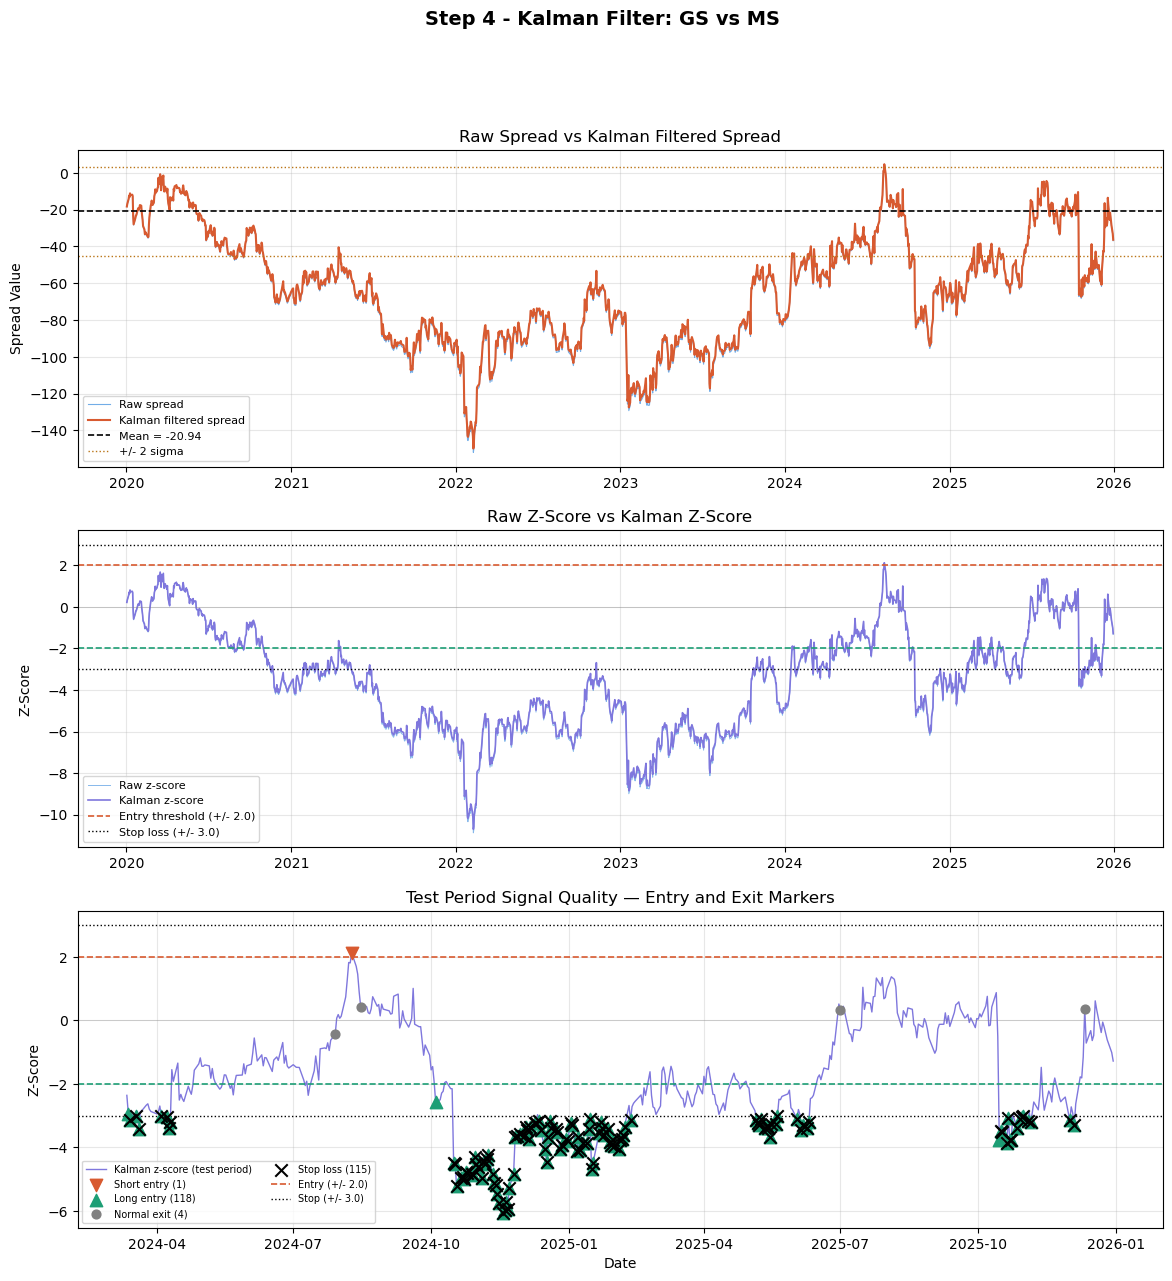

In [ ]:
# ─────────────────────────────────────────
# KALMAN FILTER IMPLEMENTATION
# ─────────────────────────────────────────

def kalman_filter(spread_data, lambda_, sigma, R=0.1):
    """
    Simple Kalman filter for AR(1) mean reversion

    spread_data: array of observed spread values
    lambda_:     AR(1) coefficient
    sigma:       process noise
    R:           observation noise
    """

    n           = len(spread_data)
    estimates   = np.zeros(n)
    uncertainty = np.zeros(n)
    gains       = np.zeros(n)

    # Initialize at first observation
    estimates[0]   = spread_data[0]
    uncertainty[0] = sigma**2

    for t in range(1, n):

        # ── PREDICT ──────────────────────────
        predicted   = lambda_ * estimates[t-1]
        P_predicted = lambda_**2 * uncertainty[t-1] + sigma**2

        # ── KALMAN GAIN ───────────────────────
        K = P_predicted / (P_predicted + R)
        gains[t] = K

        # ── UPDATE ────────────────────────────
        estimates[t]   = predicted + K * \
                         (spread_data[t] - predicted)
        uncertainty[t] = (1 - K) * P_predicted

    return estimates, uncertainty, gains

# ─────────────────────────────────────────
# APPLY KALMAN FILTER TO FULL SPREAD
# ─────────────────────────────────────────

kalman_estimates, kalman_uncertainty, kalman_gains = \
    kalman_filter(spread,
                  lambda_train,
                  sigma_train,
                  R=2.0)

kalman_series = pd.Series(kalman_estimates,
                           index=spread_series.index)

# ─────────────────────────────────────────
# CALCULATE Z-SCORES
# ─────────────────────────────────────────

# Raw z-score
z_raw    = (spread - mu_train) / sigma_train

# Kalman z-score
z_kalman = (kalman_estimates - mu_train) / sigma_train

z_raw_series    = pd.Series(z_raw,
                              index=spread_series.index)
z_kalman_series = pd.Series(z_kalman,
                              index=spread_series.index)

# ─────────────────────────────────────────
# PRINT COMPARISON
# ─────────────────────────────────────────

print("=" * 55)
print("KALMAN FILTER RESULTS")
print(f"Pair: {TICKER1} vs {TICKER2}")
print("=" * 55)

print(f"\nRAW SPREAD:")
print(f"  Mean:           {np.mean(spread):.4f}")
print(f"  Std dev:        {np.std(spread):.4f}")
print(f"  Max z-score:    {np.max(np.abs(z_raw)):.4f}")

print(f"\nKALMAN FILTERED SPREAD:")
print(f"  Mean:           {np.mean(kalman_estimates):.4f}")
print(f"  Std dev:        {np.std(kalman_estimates):.4f}")
print(f"  Max z-score:    {np.max(np.abs(z_kalman)):.4f}")

print(f"\nAVERAGE KALMAN GAIN: {np.mean(kalman_gains):.4f}")
print(f"  (0 = trust model, 1 = trust observation)")

# Count signals
raw_signals    = np.sum(np.abs(z_raw) > ENTRY_Z)
kalman_signals = np.sum(np.abs(z_kalman) > ENTRY_Z)

print(f"\nSIGNAL COMPARISON:")
print(f"  Raw z-score signals:    {raw_signals}")
print(f"  Kalman z-score signals: {kalman_signals}")
print(f"  Signal reduction:       "
      f"{raw_signals - kalman_signals} fewer signals")

if kalman_signals < raw_signals:
    print(f"\nKalman filter reduced noise signals")
    print(f"Fewer but higher quality trades expected")
else:
    print(f"\nSimilar number of signals")

# Store for later cells
kalman_results = {
    'estimates':   kalman_estimates,
    'uncertainty': kalman_uncertainty,
    'gains':       kalman_gains,
    'z_raw':       z_raw,
    'z_kalman':    z_kalman,
    'z_raw_series':    z_raw_series,
    'z_kalman_series': z_kalman_series,
    'kalman_series':   kalman_series
}

# ─────────────────────────────────────────
# VISUALIZE
# ─────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle(f'Step 4 - Kalman Filter: {TICKER1} vs {TICKER2}',
             fontsize=14, fontweight='bold')

# Plot 1 - Raw vs Kalman spread
axes[0].plot(spread_series.index,
             spread_series.values,
             color='#378ADD', lw=0.8,
             alpha=0.7,
             label='Raw spread')
axes[0].plot(kalman_series.index,
             kalman_series.values,
             color='#D85A30', lw=1.5,
             label='Kalman filtered spread')
axes[0].axhline(y=mu_train,
                color='black', ls='--', lw=1.2,
                label=f'Mean = {mu_train:.2f}')
axes[0].axhline(y=mu_train + 2*sigma_train,
                color='#BA7517', ls=':', lw=1.0,
                label='+/- 2 sigma')
axes[0].axhline(y=mu_train - 2*sigma_train,
                color='#BA7517', ls=':', lw=1.0)
axes[0].set_title('Raw Spread vs Kalman Filtered Spread')
axes[0].set_ylabel('Spread Value')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot 2 - Raw vs Kalman z-score
axes[1].plot(z_raw_series.index,
             z_raw_series.values,
             color='#378ADD', lw=0.7,
             alpha=0.6,
             label='Raw z-score')
axes[1].plot(z_kalman_series.index,
             z_kalman_series.values,
             color='#7F77DD', lw=1.2,
             label='Kalman z-score')
axes[1].axhline(y=ENTRY_Z,
                color='#D85A30', ls='--', lw=1.2,
                label=f'Entry threshold (+/- {ENTRY_Z})')
axes[1].axhline(y=-ENTRY_Z,
                color='#1D9E75', ls='--', lw=1.2)
axes[1].axhline(y=STOP_Z,
                color='black', ls=':', lw=1.0,
                label=f'Stop loss (+/- {STOP_Z})')
axes[1].axhline(y=-STOP_Z,
                color='black', ls=':', lw=1.0)
axes[1].axhline(y=0,
                color='gray', ls='-',
                lw=0.5, alpha=0.5)
axes[1].set_title('Raw Z-Score vs Kalman Z-Score')
axes[1].set_ylabel('Z-Score')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Plot 3 - Kalman uncertainty over time
# ─────────────────────────────────────────
# CHART 3 - TEST PERIOD SIGNAL QUALITY
# ─────────────────────────────────────────

test_dates = dates_all[split:]
z_test     = z_kalman[split:]

entry_dates = []
entry_zvals = []
entry_dirs  = []
exit_dates  = []
exit_zvals  = []
exit_types  = []

position = 0
for t in range(1, len(z_test)):
    z = z_test[t]

    if position != 0:
        if abs(z) < EXIT_Z:
            exit_dates.append(test_dates[t])
            exit_zvals.append(z)
            exit_types.append('normal')
            position = 0
        elif (position == -1 and z > STOP_Z) or \
             (position ==  1 and z < -STOP_Z):
            exit_dates.append(test_dates[t])
            exit_zvals.append(z)
            exit_types.append('stop')
            position = 0

    if position == 0:
        if z > ENTRY_Z:
            entry_dates.append(test_dates[t])
            entry_zvals.append(z)
            entry_dirs.append('short')
            position = -1
        elif z < -ENTRY_Z:
            entry_dates.append(test_dates[t])
            entry_zvals.append(z)
            entry_dirs.append('long')
            position = 1

short_entry_d = [d for d, dr in zip(entry_dates, entry_dirs) if dr == 'short']
short_entry_z = [z for z, dr in zip(entry_zvals, entry_dirs) if dr == 'short']
long_entry_d  = [d for d, dr in zip(entry_dates, entry_dirs) if dr == 'long']
long_entry_z  = [z for z, dr in zip(entry_zvals, entry_dirs) if dr == 'long']
normal_exit_d = [d for d, et in zip(exit_dates, exit_types) if et == 'normal']
normal_exit_z = [z for z, et in zip(exit_zvals, exit_types) if et == 'normal']
stop_exit_d   = [d for d, et in zip(exit_dates, exit_types) if et == 'stop']
stop_exit_z   = [z for z, et in zip(exit_zvals, exit_types) if et == 'stop']

axes[2].plot(test_dates, z_test, color='#7F77DD', lw=1.0, label='Kalman z-score (test period)')
axes[2].scatter(short_entry_d, short_entry_z, color='#D85A30', marker='v', s=80, zorder=5, label=f'Short entry ({len(short_entry_d)})')
axes[2].scatter(long_entry_d,  long_entry_z,  color='#1D9E75', marker='^', s=80, zorder=5, label=f'Long entry ({len(long_entry_d)})')
axes[2].scatter(normal_exit_d, normal_exit_z, color='gray',    marker='o', s=40, zorder=5, label=f'Normal exit ({len(normal_exit_d)})')
axes[2].scatter(stop_exit_d,   stop_exit_z,   color='black',   marker='x', s=80, zorder=5, label=f'Stop loss ({len(stop_exit_d)})')
axes[2].axhline(y=ENTRY_Z,  color='#D85A30', ls='--', lw=1.2, label=f'Entry (+/- {ENTRY_Z})')
axes[2].axhline(y=-ENTRY_Z, color='#1D9E75', ls='--', lw=1.2)
axes[2].axhline(y=STOP_Z,   color='black',   ls=':',  lw=1.0, label=f'Stop (+/- {STOP_Z})')
axes[2].axhline(y=-STOP_Z,  color='black',   ls=':',  lw=1.0)
axes[2].axhline(y=0,        color='gray',     ls='-',  lw=0.5, alpha=0.4)
axes[2].set_title('Test Period Signal Quality — Entry and Exit Markers')
axes[2].set_ylabel('Z-Score')
axes[2].set_xlabel('Date')
axes[2].legend(fontsize=7, ncol=2)
axes[2].grid(True, alpha=0.3)

## Step 5 - Backtesting the Strategy

The backtest is the **first honest test** of the strategy.
We apply the trading rules to the test data — the 30% of data
the model has never seen — and measure exactly how much money
it would have made or lost.

### Trading Rules

$$\text{If } z_t > +2.0 \Rightarrow \text{SHORT spread} \quad (\text{sell } TICKER1, \text{buy } TICKER2)$$
$$\text{If } z_t < -2.0 \Rightarrow \text{LONG spread} \quad (\text{buy } TICKER1, \text{sell } TICKER2)$$
$$\text{If } |z_t| < 0.5 \Rightarrow \text{CLOSE position} \quad (\text{take profit})$$
$$\text{If } |z_t| > 3.0 \Rightarrow \text{STOP LOSS} \quad (\text{exit immediately})$$

### Why We Use the Test Set

Using the same data to build AND test the model would be like
studying the exact exam questions and then taking that exact exam.
You would always get 100% but learn nothing about real performance.

The test set simulates live trading — the model makes decisions
based only on what it learned from training data, applied to
prices it has never seen before.

### Performance Metrics

| Metric | Formula | Good value |
|--------|---------|-----------|
| Total return | $\frac{V_T - V_0}{V_0} \times 100$ | Above 0% |
| Win rate | $\frac{\text{Winning trades}}{\text{Total trades}}$ | Above 50% |
| Sharpe ratio | $\frac{E[r]}{\sigma_r} \times \sqrt{252}$ | Above 0.5 |
| Max drawdown | $\min\left(\frac{V_t - \max_{s \leq t} V_s}{\max_{s \leq t} V_s}\right)$ | Above -20% |

The **Sharpe ratio** is the most important single metric — it measures
return per unit of risk taken. A Sharpe above 1.0 is considered good
in professional fund management.

BACKTEST RESULTS - TEST DATA ONLY
Period: 2024-03-12 to 2025-12-30

RAW Z-SCORE
----------------------------------------
Total trades:      97
Winning trades:    1
Losing trades:     96
Stop losses hit:   96
Win rate:          1.0%
Average win:       $28.72
Average loss:      $-5.27
Profit factor:     0.06
Total return:      -9.67%
Sharpe ratio:      0.12
Max drawdown:      -9.71%

Score: 1/5
POOR - Strategy needs rethinking

KALMAN FILTERED
----------------------------------------
Total trades:      97
Winning trades:    1
Losing trades:     96
Stop losses hit:   96
Win rate:          1.0%
Average win:       $28.72
Average loss:      $-5.27
Profit factor:     0.06
Total return:      -9.67%
Sharpe ratio:      0.12
Max drawdown:      -9.71%

Score: 1/5
POOR - Strategy needs rethinking

COMPARISON: RAW vs KALMAN
Metric                        Raw       Kalman
---------------------------------------------
Total return               -9.67%       -9.67%
Win rate                     1.0%     

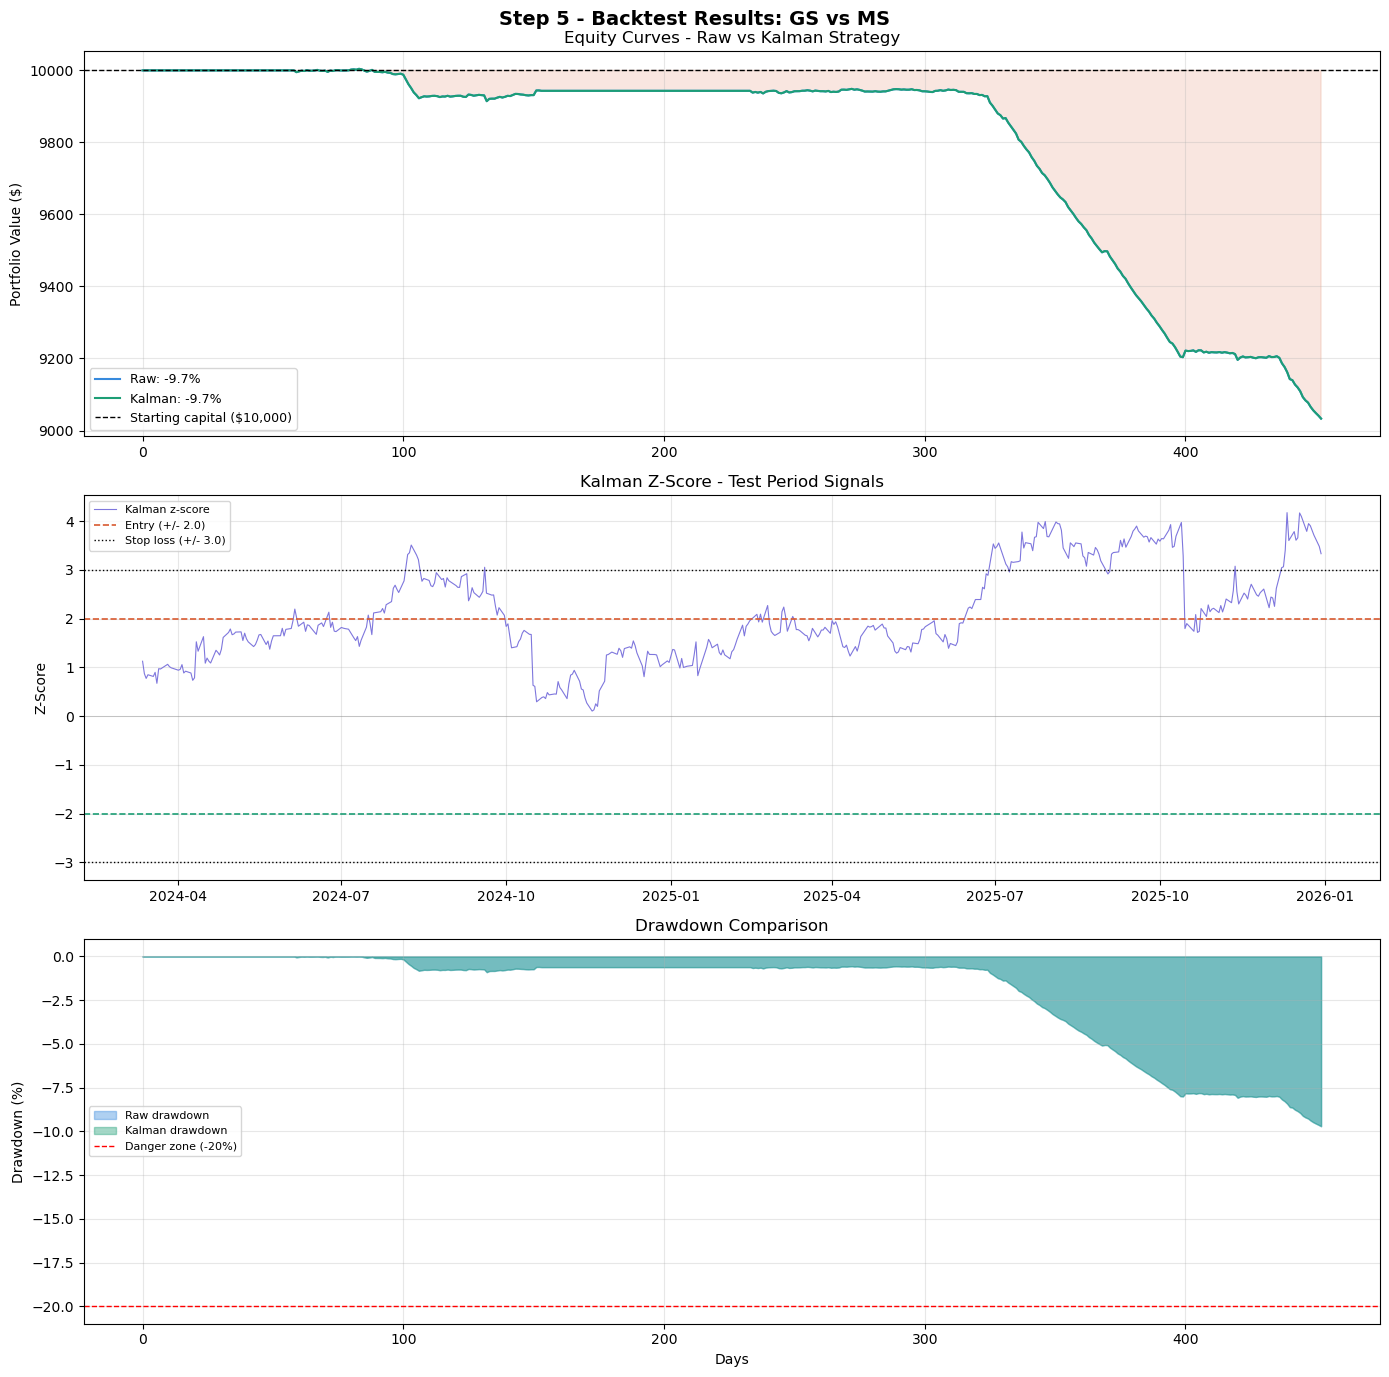

Chart saved as step5_backtest.png


In [ ]:
# ─────────────────────────────────────────
# BACKTEST FUNCTION
# ─────────────────────────────────────────

def run_backtest(spread_data, z_scores,
                 mu, sigma,
                 entry_z = 2.0,
                 exit_z  = 0.5,
                 stop_z  = 3.0,
                 capital = 10000,
                 cost    = 5.0,
                 label   = 'Strategy'):

    position    = 0       # 1=long, -1=short, 0=flat
    entry_price = 0
    entry_z_val = 0

    trades      = []
    daily_pnl   = [0]
    equity      = [capital]
    z_history   = [z_scores[0]]

    for t in range(1, len(spread_data)):

        z = z_scores[t]
        z_history.append(z)

        # Daily P/L from open position
        if position != 0:
            price_change = spread_data[t] - spread_data[t-1]
            day_pnl      = position * price_change
            daily_pnl.append(day_pnl)
            equity.append(equity[-1] + day_pnl)
        else:
            daily_pnl.append(0)
            equity.append(equity[-1])

        # Check exit conditions
        if position != 0:

            # Normal exit
            if abs(z) < exit_z:
                pnl = position * \
                      (spread_data[t] - entry_price) - cost
                trades.append({
                    'exit_type': 'NORMAL',
                    'entry_z':   entry_z_val,
                    'exit_z':    z,
                    'pnl':       pnl,
                    'win':       pnl > 0
                })
                equity[-1] -= cost
                position    = 0

            # Stop loss
            elif (position == -1 and z >  stop_z) or \
                 (position ==  1 and z < -stop_z):
                pnl = position * \
                      (spread_data[t] - entry_price) - cost
                trades.append({
                    'exit_type': 'STOP LOSS',
                    'entry_z':   entry_z_val,
                    'exit_z':    z,
                    'pnl':       pnl,
                    'win':       False
                })
                equity[-1] -= cost
                position    = 0

        # Check entry conditions
        if position == 0:

            if z > entry_z:
                position    = -1
                entry_price = spread_data[t]
                entry_z_val = z
                equity[-1] -= cost

            elif z < -entry_z:
                position    = 1
                entry_price = spread_data[t]
                entry_z_val = z
                equity[-1] -= cost

    # Calculate statistics
    equity    = np.array(equity)
    daily_pnl = np.array(daily_pnl)
    n_trades  = len(trades)

    if n_trades > 0:
        wins         = [t for t in trades if t['win']]
        losses       = [t for t in trades if not t['win']]
        stop_losses  = [t for t in trades
                        if t['exit_type'] == 'STOP LOSS']
        win_rate     = len(wins) / n_trades * 100
        avg_win      = np.mean([t['pnl'] for t in wins]) \
                       if wins else 0
        avg_loss     = np.mean([t['pnl'] for t in losses]) \
                       if losses else 0
        total_pnl    = sum(t['pnl'] for t in trades)
        win_pnl      = sum(t['pnl'] for t in wins) \
                       if wins else 0
        loss_pnl     = abs(sum(t['pnl'] for t in losses)) \
                       if losses else 1
        pf           = win_pnl / loss_pnl \
                       if loss_pnl > 0 else 999
    else:
        wins = losses = stop_losses = []
        win_rate = avg_win = avg_loss = 0
        total_pnl = pf = 0

    # Sharpe ratio
    if np.std(daily_pnl) > 0:
        sharpe = np.mean(daily_pnl) / \
                 np.std(daily_pnl) * np.sqrt(252)
    else:
        sharpe = 0

    # Max drawdown
    peak     = np.maximum.accumulate(equity)
    drawdown = (equity - peak) / peak * 100
    max_dd   = np.min(drawdown)

    # Total return
    total_return = (equity[-1] - equity[0]) / \
                    equity[0] * 100

    return {
        'label':        label,
        'equity':       equity,
        'daily_pnl':    daily_pnl,
        'drawdown':     drawdown,
        'trades':       trades,
        'n_trades':     n_trades,
        'win_rate':     win_rate,
        'avg_win':      avg_win,
        'avg_loss':     avg_loss,
        'total_pnl':    total_pnl,
        'profit_factor': pf,
        'sharpe':       sharpe,
        'max_dd':       max_dd,
        'total_return': total_return,
        'stop_losses':  len(stop_losses),
        'n_wins':       len(wins),
        'n_losses':     len(losses)
    }

# ─────────────────────────────────────────
# RUN BOTH BACKTESTS ON TEST DATA
# ─────────────────────────────────────────

# Get test period z-scores
z_raw_test    = kalman_results['z_raw'][split:]
z_kalman_test = kalman_results['z_kalman'][split:]

# Run raw strategy
results_raw = run_backtest(
    spread_data = test,
    z_scores    = z_raw_test,
    mu          = mu_train,
    sigma       = sigma_train,
    entry_z     = ENTRY_Z,
    exit_z      = EXIT_Z,
    stop_z      = STOP_Z,
    capital     = CAPITAL,
    cost        = COST,
    label       = 'Raw Z-Score'
)

# Run Kalman strategy
results_kalman = run_backtest(
    spread_data = test,
    z_scores    = z_kalman_test,
    mu          = mu_train,
    sigma       = sigma_train,
    entry_z     = ENTRY_Z,
    exit_z      = EXIT_Z,
    stop_z      = STOP_Z,
    capital     = CAPITAL,
    cost        = COST,
    label       = 'Kalman Filtered'
)

# ─────────────────────────────────────────
# PRINT RESULTS
# ─────────────────────────────────────────

def print_results(r):
    print(f"\n{r['label'].upper()}")
    print(f"-" * 40)
    print(f"Total trades:      {r['n_trades']}")
    print(f"Winning trades:    {r['n_wins']}")
    print(f"Losing trades:     {r['n_losses']}")
    print(f"Stop losses hit:   {r['stop_losses']}")
    print(f"Win rate:          {r['win_rate']:.1f}%")
    print(f"Average win:       ${r['avg_win']:.2f}")
    print(f"Average loss:      ${r['avg_loss']:.2f}")
    print(f"Profit factor:     {r['profit_factor']:.2f}")
    print(f"Total return:      {r['total_return']:.2f}%")
    print(f"Sharpe ratio:      {r['sharpe']:.2f}")
    print(f"Max drawdown:      {r['max_dd']:.2f}%")

    score = 0
    if r['total_return']  > 0:    score += 1
    if r['win_rate']      > 50:   score += 1
    if r['sharpe']        > 0.5:  score += 1
    if r['max_dd']        > -20:  score += 1
    if r['profit_factor'] > 1.2:  score += 1

    print(f"\nScore: {score}/5")
    if score >= 4:
        print(f"GOOD - Strategy shows real edge")
    elif score >= 3:
        print(f"OK - Some edge but needs work")
    else:
        print(f"POOR - Strategy needs rethinking")

print("=" * 55)
print("BACKTEST RESULTS - TEST DATA ONLY")
print(f"Period: {dates_test[0].date()} to "
      f"{dates_test[-1].date()}")
print("=" * 55)

print_results(results_raw)
print_results(results_kalman)

# Comparison
print(f"\n{'=' * 55}")
print(f"COMPARISON: RAW vs KALMAN")
print(f"{'=' * 55}")
print(f"{'Metric':<20} {'Raw':>12} {'Kalman':>12}")
print(f"-" * 45)
print(f"{'Total return':<20} "
      f"{results_raw['total_return']:>11.2f}% "
      f"{results_kalman['total_return']:>11.2f}%")
print(f"{'Win rate':<20} "
      f"{results_raw['win_rate']:>11.1f}% "
      f"{results_kalman['win_rate']:>11.1f}%")
print(f"{'Sharpe ratio':<20} "
      f"{results_raw['sharpe']:>12.2f} "
      f"{results_kalman['sharpe']:>12.2f}")
print(f"{'Max drawdown':<20} "
      f"{results_raw['max_dd']:>11.2f}% "
      f"{results_kalman['max_dd']:>11.2f}%")
print(f"{'Profit factor':<20} "
      f"{results_raw['profit_factor']:>12.2f} "
      f"{results_kalman['profit_factor']:>12.2f}")
print(f"{'Total trades':<20} "
      f"{results_raw['n_trades']:>12} "
      f"{results_kalman['n_trades']:>12}")

if results_kalman['total_return'] > results_raw['total_return']:
    print(f"\nKalman filter IMPROVED performance")
    print(f"Use Kalman signals for live trading")
else:
    print(f"\nRaw signals performed better")
    print(f"Kalman filter added noise in this case")

# Store for later cells
backtest_results = {
    'raw':    results_raw,
    'kalman': results_kalman
}

# ─────────────────────────────────────────
# VISUALIZE
# ─────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle(f'Step 5 - Backtest Results: '
             f'{TICKER1} vs {TICKER2}',
             fontsize=14, fontweight='bold')

# Plot 1 - Equity curves
axes[0].plot(results_raw['equity'],
             color='#378ADD', lw=1.5,
             label=f"Raw: {results_raw['total_return']:.1f}%")
axes[0].plot(results_kalman['equity'],
             color='#1D9E75', lw=1.5,
             label=f"Kalman: {results_kalman['total_return']:.1f}%")
axes[0].axhline(y=CAPITAL,
                color='black', ls='--', lw=1.0,
                label=f'Starting capital (${CAPITAL:,})')
axes[0].fill_between(range(len(results_kalman['equity'])),
                      results_kalman['equity'],
                      CAPITAL,
                      where=(results_kalman['equity'] >= CAPITAL),
                      alpha=0.15, color='#1D9E75')
axes[0].fill_between(range(len(results_kalman['equity'])),
                      results_kalman['equity'],
                      CAPITAL,
                      where=(results_kalman['equity'] < CAPITAL),
                      alpha=0.15, color='#D85A30')
axes[0].set_title('Equity Curves - Raw vs Kalman Strategy')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot 2 - Z-score with signals on test data
axes[1].plot(dates_test,
             z_kalman_test,
             color='#7F77DD', lw=0.8,
             label='Kalman z-score')
axes[1].axhline(y=ENTRY_Z,
                color='#D85A30', ls='--', lw=1.2,
                label=f'Entry (+/- {ENTRY_Z})')
axes[1].axhline(y=-ENTRY_Z,
                color='#1D9E75', ls='--', lw=1.2)
axes[1].axhline(y=STOP_Z,
                color='black', ls=':', lw=1.0,
                label=f'Stop loss (+/- {STOP_Z})')
axes[1].axhline(y=-STOP_Z,
                color='black', ls=':', lw=1.0)
axes[1].axhline(y=0,
                color='gray', ls='-',
                lw=0.5, alpha=0.5)
axes[1].set_title('Kalman Z-Score - Test Period Signals')
axes[1].set_ylabel('Z-Score')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Plot 3 - Drawdown comparison
axes[2].fill_between(range(len(results_raw['drawdown'])),
                      results_raw['drawdown'], 0,
                      color='#378ADD', alpha=0.4,
                      label='Raw drawdown')
axes[2].fill_between(range(len(results_kalman['drawdown'])),
                      results_kalman['drawdown'], 0,
                      color='#1D9E75', alpha=0.4,
                      label='Kalman drawdown')
axes[2].axhline(y=-20,
                color='red', ls='--', lw=1.0,
                label='Danger zone (-20%)')
axes[2].set_title('Drawdown Comparison')
axes[2].set_ylabel('Drawdown (%)')
axes[2].set_xlabel('Days')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step5_backtest.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved as step5_backtest.png")

## Step 6 - Monte Carlo Simulation

The backtest showed us what happened in **one specific test period**.
But that particular 302-day window might have been unusually lucky
or unlucky. We need a stronger form of validation.

Monte Carlo simulation generates **1000 possible futures** using
our AR(1) model parameters and runs the strategy on each one:

$$r_t^{(k)} = \mu + \lambda(r_{t-1}^{(k)} - \mu) + \sigma z_t^{(k)}, \quad k = 1,...,1000$$

Each simulation uses the **same parameters** but **different random shocks**
$z_t^{(k)} \sim N(0,1)$, producing 1000 completely different spread paths.

### What This Tells Us

Instead of one backtest result we get a **probability distribution**
of all possible outcomes:

$$P(\text{profit}) = \frac{\text{Number of simulations with positive return}}{1000}$$

This is far more informative than a single backtest:

| Single Backtest | Monte Carlo |
|-----------------|-------------|
| One outcome | 1000 outcomes |
| Could be lucky | Eliminates luck |
| "Strategy made 8%" | "72% probability of profit" |
| Dangerous to rely on | Statistical foundation |

### The Key Question

If the strategy is genuinely profitable the Monte Carlo should show:
- Probability of profit above 60%
- Positive average return across all simulations
- Worst case scenario is survivable

If Monte Carlo fails even when backtest passes — the backtest
was likely a lucky outcome not representative of the true edge.

### Connection to the Ornstein-Uhlenbeck Process

In continuous time the AR(1) model becomes the
**Ornstein-Uhlenbeck process**:

$$dX_t = \theta(\mu - X_t)dt + \sigma dW_t$$

Where $\theta = -\ln(\lambda)/\Delta t$ is the mean reversion speed
and $W_t$ is a Wiener process. The Monte Carlo simulation is a
discrete time approximation of this continuous process.

MONTE CARLO SIMULATION
Pair: GS vs MS
Running 1000 simulations...
Days per simulation: 453

  Running simulation 0/1000...
  Running simulation 200/1000...
  Running simulation 400/1000...
  Running simulation 600/1000...
  Running simulation 800/1000...

MONTE CARLO RESULTS

RAW STRATEGY (1000 simulations):
----------------------------------------
Probability of profit:   100.0%
Average return:          3.44%
Median return:           3.43%
Best 5% scenario:        4.75%
Worst 5% scenario:       2.22%
Std dev of returns:      0.77%

KALMAN STRATEGY (1000 simulations):
----------------------------------------
Probability of profit:   100.0%
Average return:          3.31%
Median return:           3.28%
Best 5% scenario:        4.55%
Worst 5% scenario:       2.06%
Average win rate:        99.8%
Average Sharpe:          2.29
Average max drawdown:    -0.42%
Worst max drawdown:      -0.85%
Average trades per sim:  18

MONTE CARLO VERDICT
STRONG - Strategy profitable in majority
of simulation

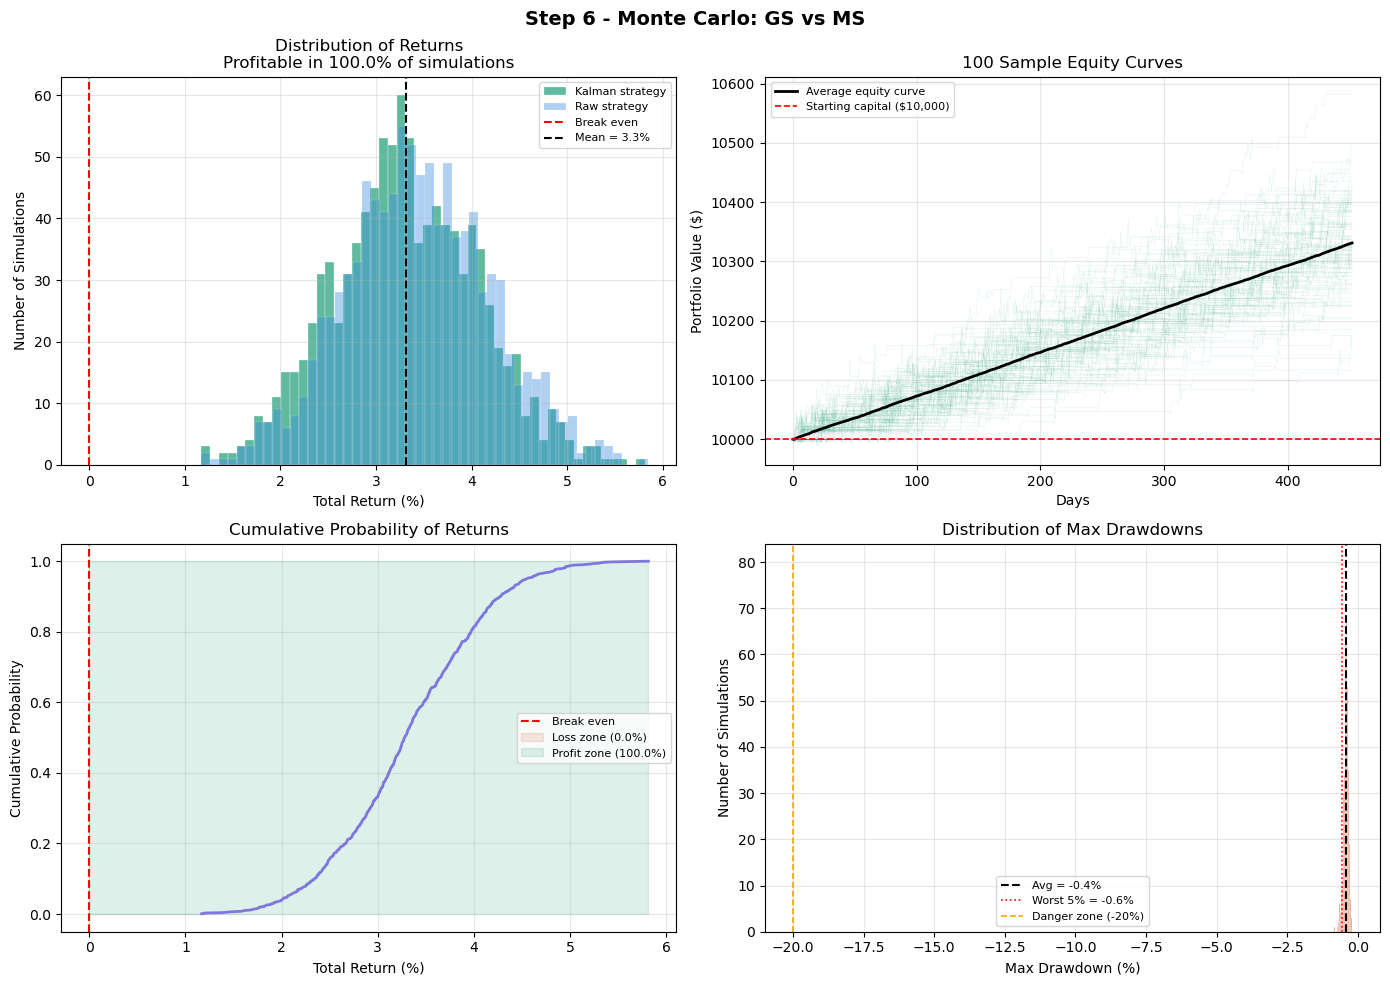

Chart saved as step6_monte_carlo.png


In [ ]:
# ─────────────────────────────────────────
# MONTE CARLO SIMULATION
# ─────────────────────────────────────────

def simulate_ar1_path(mu, sigma, lambda_,
                       n_days, start_val=None):
    """
    Simulate one AR(1) path
    """
    if start_val is None:
        start_val = mu

    path    = [start_val]
    current = start_val

    for day in range(n_days - 1):
        z        = np.random.normal(0, 1)
        next_val = mu + lambda_ * (current - mu) + sigma * z
        path.append(next_val)
        current  = next_val

    return np.array(path)

# ─────────────────────────────────────────
# RUN MONTE CARLO
# ─────────────────────────────────────────

n_simulations = 1000
n_days        = len(test)
np.random.seed(42)

print("=" * 55)
print("MONTE CARLO SIMULATION")
print(f"Pair: {TICKER1} vs {TICKER2}")
print("=" * 55)
print(f"Running {n_simulations} simulations...")
print(f"Days per simulation: {n_days}")
print()

# Store results
mc_returns_raw    = []
mc_returns_kalman = []
mc_win_rates      = []
mc_sharpes        = []
mc_max_dds        = []
mc_n_trades       = []
mc_equity_curves  = []

for sim in range(n_simulations):

    if sim % 200 == 0:
        print(f"  Running simulation {sim}/{n_simulations}...")

    # Simulate spread path
    sim_spread = simulate_ar1_path(
        mu       = mu_train,
        sigma    = sigma_train,
        lambda_  = lambda_train,
        n_days   = n_days
    )

    # Calculate z-scores for simulated path
    sim_z = (sim_spread - mu_train) / sigma_train

    # Apply Kalman filter to simulated path
    sim_kalman, _, _ = kalman_filter(
        sim_spread,
        lambda_train,
        sigma_train,
        R=2.0
    )
    sim_z_kalman = (sim_kalman - mu_train) / sigma_train

    # Run backtest on raw simulated path
    sim_raw = run_backtest(
        spread_data = sim_spread,
        z_scores    = sim_z,
        mu          = mu_train,
        sigma       = sigma_train,
        entry_z     = ENTRY_Z,
        exit_z      = EXIT_Z,
        stop_z      = STOP_Z,
        capital     = CAPITAL,
        cost        = COST,
        label       = 'MC Raw'
    )

    # Run backtest on Kalman simulated path
    sim_kal = run_backtest(
        spread_data = sim_spread,
        z_scores    = sim_z_kalman,
        mu          = mu_train,
        sigma       = sigma_train,
        entry_z     = ENTRY_Z,
        exit_z      = EXIT_Z,
        stop_z      = STOP_Z,
        capital     = CAPITAL,
        cost        = COST,
        label       = 'MC Kalman'
    )

    mc_returns_raw.append(sim_raw['total_return'])
    mc_returns_kalman.append(sim_kal['total_return'])
    mc_win_rates.append(sim_kal['win_rate'])
    mc_sharpes.append(sim_kal['sharpe'])
    mc_max_dds.append(sim_kal['max_dd'])
    mc_n_trades.append(sim_kal['n_trades'])
    mc_equity_curves.append(sim_kal['equity'])

# Convert to arrays
mc_returns_raw    = np.array(mc_returns_raw)
mc_returns_kalman = np.array(mc_returns_kalman)
mc_win_rates      = np.array(mc_win_rates)
mc_sharpes        = np.array(mc_sharpes)
mc_max_dds        = np.array(mc_max_dds)
mc_n_trades       = np.array(mc_n_trades)

# ─────────────────────────────────────────
# PRINT RESULTS
# ─────────────────────────────────────────

prob_profit_raw    = np.mean(mc_returns_raw > 0) * 100
prob_profit_kalman = np.mean(mc_returns_kalman > 0) * 100

print()
print("=" * 55)
print("MONTE CARLO RESULTS")
print("=" * 55)

print(f"\nRAW STRATEGY ({n_simulations} simulations):")
print(f"-" * 40)
print(f"Probability of profit:   {prob_profit_raw:.1f}%")
print(f"Average return:          {np.mean(mc_returns_raw):.2f}%")
print(f"Median return:           {np.median(mc_returns_raw):.2f}%")
print(f"Best 5% scenario:        {np.percentile(mc_returns_raw, 95):.2f}%")
print(f"Worst 5% scenario:       {np.percentile(mc_returns_raw, 5):.2f}%")
print(f"Std dev of returns:      {np.std(mc_returns_raw):.2f}%")

print(f"\nKALMAN STRATEGY ({n_simulations} simulations):")
print(f"-" * 40)
print(f"Probability of profit:   {prob_profit_kalman:.1f}%")
print(f"Average return:          {np.mean(mc_returns_kalman):.2f}%")
print(f"Median return:           {np.median(mc_returns_kalman):.2f}%")
print(f"Best 5% scenario:        {np.percentile(mc_returns_kalman, 95):.2f}%")
print(f"Worst 5% scenario:       {np.percentile(mc_returns_kalman, 5):.2f}%")
print(f"Average win rate:        {np.mean(mc_win_rates):.1f}%")
print(f"Average Sharpe:          {np.mean(mc_sharpes):.2f}")
print(f"Average max drawdown:    {np.mean(mc_max_dds):.2f}%")
print(f"Worst max drawdown:      {np.min(mc_max_dds):.2f}%")
print(f"Average trades per sim:  {np.mean(mc_n_trades):.0f}")

print(f"\n{'=' * 55}")
print(f"MONTE CARLO VERDICT")
print(f"{'=' * 55}")

if prob_profit_kalman > 65 and \
   np.mean(mc_returns_kalman) > 0:
    print(f"STRONG - Strategy profitable in majority")
    print(f"of simulations. Proceed to live trading.")
    mc_verdict = 'STRONG'
elif prob_profit_kalman > 50:
    print(f"MODERATE - Strategy profitable in more")
    print(f"than half of simulations. Trade carefully.")
    mc_verdict = 'MODERATE'
else:
    print(f"WEAK - Strategy unprofitable in majority")
    print(f"of simulations. Do not trade.")
    mc_verdict = 'WEAK'

# Store for final verdict
mc_results = {
    'returns_raw':      mc_returns_raw,
    'returns_kalman':   mc_returns_kalman,
    'win_rates':        mc_win_rates,
    'sharpes':          mc_sharpes,
    'max_dds':          mc_max_dds,
    'n_trades':         mc_n_trades,
    'equity_curves':    mc_equity_curves,
    'prob_profit_raw':  prob_profit_raw,
    'prob_profit_kalman': prob_profit_kalman,
    'verdict':          mc_verdict
}

# ─────────────────────────────────────────
# VISUALIZE
# ─────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Step 6 - Monte Carlo: {TICKER1} vs {TICKER2}',
             fontsize=14, fontweight='bold')

# Plot 1 - Distribution of returns
axes[0, 0].hist(mc_returns_kalman,
                bins=50,
                color='#1D9E75',
                alpha=0.7,
                edgecolor='white',
                lw=0.3,
                label='Kalman strategy')
axes[0, 0].hist(mc_returns_raw,
                bins=50,
                color='#378ADD',
                alpha=0.4,
                edgecolor='white',
                lw=0.3,
                label='Raw strategy')
axes[0, 0].axvline(x=0,
                    color='red', ls='--', lw=1.5,
                    label='Break even')
axes[0, 0].axvline(x=np.mean(mc_returns_kalman),
                    color='black', ls='--', lw=1.5,
                    label=f'Mean = '
                          f'{np.mean(mc_returns_kalman):.1f}%')
axes[0, 0].set_title(f'Distribution of Returns\n'
                      f'Profitable in '
                      f'{prob_profit_kalman:.1f}% of simulations')
axes[0, 0].set_xlabel('Total Return (%)')
axes[0, 0].set_ylabel('Number of Simulations')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2 - Sample equity curves
for i in range(min(100, n_simulations)):
    axes[0, 1].plot(mc_equity_curves[i],
                    color='#1D9E75',
                    lw=0.3,
                    alpha=0.15)

avg_equity = np.mean(mc_equity_curves, axis=0)
axes[0, 1].plot(avg_equity,
                color='black', lw=2.0,
                label='Average equity curve')
axes[0, 1].axhline(y=CAPITAL,
                    color='red', ls='--', lw=1.2,
                    label=f'Starting capital (${CAPITAL:,})')
axes[0, 1].set_title('100 Sample Equity Curves')
axes[0, 1].set_ylabel('Portfolio Value ($)')
axes[0, 1].set_xlabel('Days')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3 - Cumulative probability
sorted_returns = np.sort(mc_returns_kalman)
cumulative     = np.arange(1, len(sorted_returns) + 1) / \
                 len(sorted_returns)

axes[1, 0].plot(sorted_returns, cumulative,
                color='#7F77DD', lw=2.0)
axes[1, 0].axvline(x=0,
                    color='red', ls='--', lw=1.5,
                    label='Break even')
axes[1, 0].fill_betweenx(
    [0, 1 - prob_profit_kalman/100],
    sorted_returns.min(), 0,
    alpha=0.15, color='#D85A30',
    label=f'Loss zone '
          f'({100-prob_profit_kalman:.1f}%)')
axes[1, 0].fill_betweenx(
    [1 - prob_profit_kalman/100, 1],
    0, sorted_returns.max(),
    alpha=0.15, color='#1D9E75',
    label=f'Profit zone '
          f'({prob_profit_kalman:.1f}%)')
axes[1, 0].set_title('Cumulative Probability of Returns')
axes[1, 0].set_xlabel('Total Return (%)')
axes[1, 0].set_ylabel('Cumulative Probability')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4 - Max drawdown distribution
axes[1, 1].hist(mc_max_dds,
                bins=50,
                color='#D85A30',
                alpha=0.7,
                edgecolor='white',
                lw=0.3)
axes[1, 1].axvline(x=np.mean(mc_max_dds),
                    color='black', ls='--', lw=1.5,
                    label=f'Avg = '
                          f'{np.mean(mc_max_dds):.1f}%')
axes[1, 1].axvline(x=np.percentile(mc_max_dds, 5),
                    color='red', ls=':', lw=1.2,
                    label=f'Worst 5% = '
                          f'{np.percentile(mc_max_dds,5):.1f}%')
axes[1, 1].axvline(x=-20,
                    color='orange', ls='--', lw=1.2,
                    label='Danger zone (-20%)')
axes[1, 1].set_title('Distribution of Max Drawdowns')
axes[1, 1].set_xlabel('Max Drawdown (%)')
axes[1, 1].set_ylabel('Number of Simulations')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step6_monte_carlo.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved as step6_monte_carlo.png")
if stat_score < 3:
    print()
    print("!" * 55)
    print("WARNING: This pair failed statistical tests")
    print("Do not proceed to backtest")
    print("Change TICKER1 and TICKER2 in Cell 3")
    print("and run all cells again")
    print("!" * 55)


## Step 7 - Final Verdict

We now combine **all evidence** from every previous step into
one clear decision.

### The Decision Framework

The strategy requires three independent confirmations:

**1. Statistical confirmation** — does mean reversion exist?
$$\lambda < 0 \quad \text{AND} \quad p_{ADF} < 0.05 \quad \text{AND} \quad |t| > 2$$

**2. Empirical confirmation** — did it make money on unseen data?
$$\text{Total return} > 0 \quad \text{AND} \quad \text{Win rate} > 50\%$$

**3. Probabilistic confirmation** — does it work across many futures?
$$P(\text{profit}) > 60\% \quad \text{AND} \quad E[\text{return}] > 0$$

All three must pass for a YES verdict. Failing any one section
produces a NO or PROCEED WITH CAUTION verdict.

### Why Three Independent Tests?

A single backtest can be lucky. Statistical tests confirm
the mechanism but not profitability. Monte Carlo shows
probability but assumes the model is correct.

Together they form a **triangulation** of evidence that is
much harder to fool by chance than any single test alone.

$$\text{Confidence} = f(\text{Statistics} \cap \text{Backtest} \cap \text{Monte Carlo})$$

### Limitations of This Framework

No model is perfect. Even a YES verdict carries these risks:

1. **Regime change** — lambda can turn positive ending mean reversion
2. **Fat tails** — extreme moves happen more than normal distribution predicts
3. **Transaction costs** — real costs may differ from assumed $5 per trade
4. **Market impact** — large trades move prices against you
5. **Overfitting** — parameters estimated on historical data may not persist

The appropriate response to a YES verdict is to **start small**,
monitor rolling lambda weekly, and stop immediately if lambda
turns positive or the ADF test fails.

FINAL VERDICT
Pair: GS vs MS
Period: 2020-01-01 to 2025-12-31

────────────────────────────────────────────────────────────
SECTION 1 - STATISTICAL TESTS
────────────────────────────────────────────────────────────
Test                                 Result    Verdict
──────────────────────────────────────────────────────
Correlation                          0.9828       PASS
Lambda                              -0.0109       FAIL
T-statistic                         -2.9316       PASS
Half life (days)                       63.8       FAIL
ADF p-value                        0.062912       FAIL
Lambda negative % of time             96.1%       PASS

Statistical Score: 3/5

────────────────────────────────────────────────────────────
SECTION 2 - AR(1) MODEL PARAMETERS
────────────────────────────────────────────────────────────
Mean (mu):              -20.9410
Std Dev (sigma):        12.0482
Lambda:                 -0.0109
Half life:              63.8 days
Lambda stable:          96.1% of

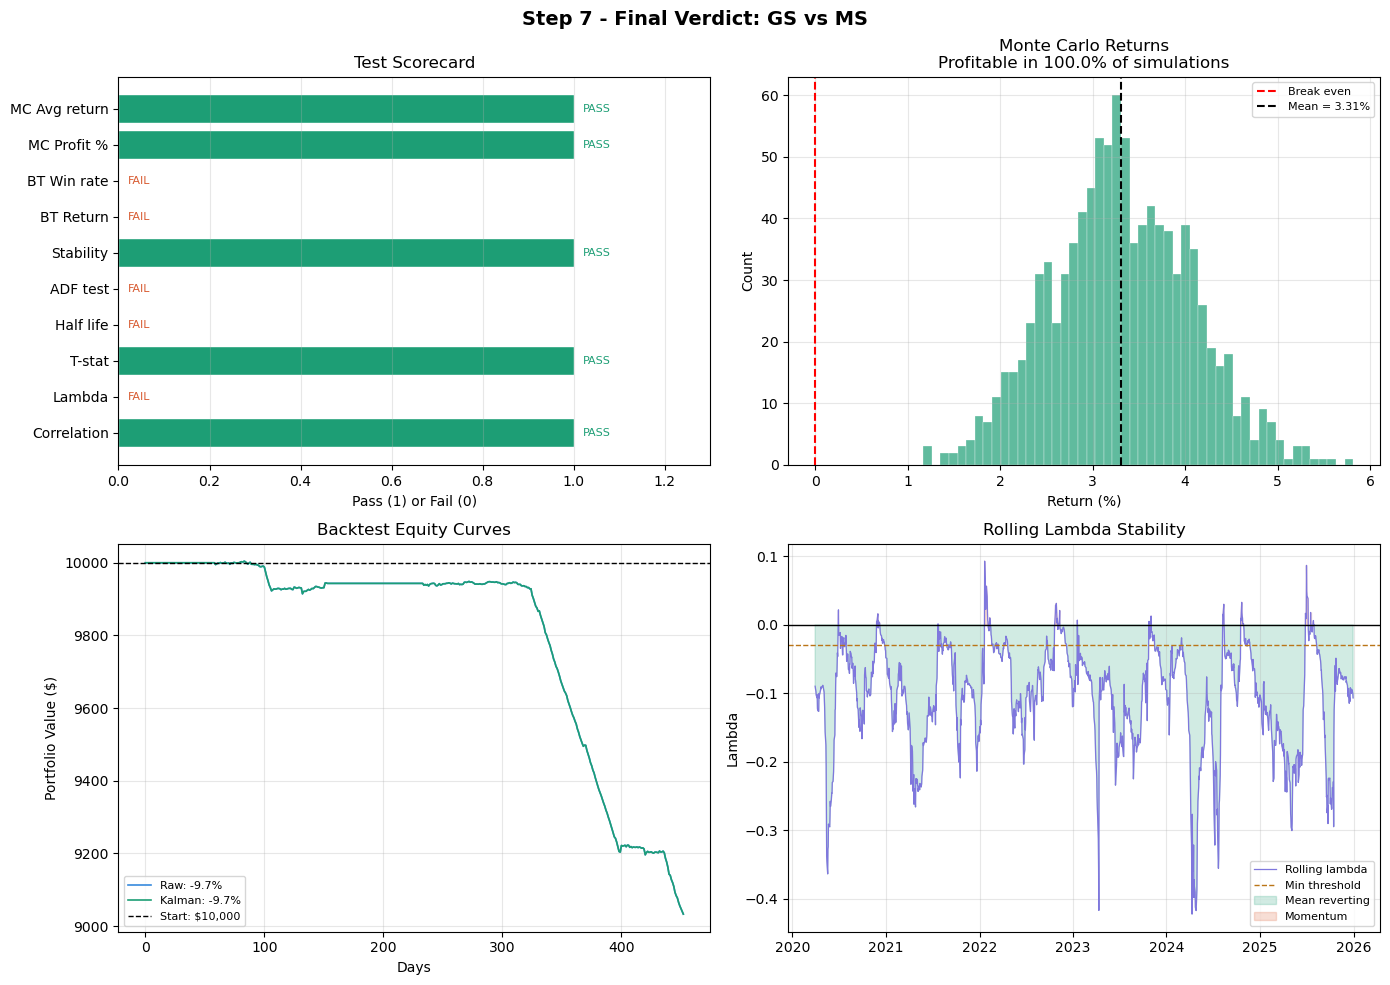

Chart saved as step7_final_verdict.png

PROJECT COMPLETE
Pair analyzed:  GS vs MS
Final verdict:  MAYBE — PROCEED WITH CAUTION
Passes:         6/12


In [ ]:
# ─────────────────────────────────────────
# FINAL VERDICT
# ─────────────────────────────────────────

print("=" * 60)
print("FINAL VERDICT")
print(f"Pair: {TICKER1} vs {TICKER2}")
print(f"Period: {START_DATE} to {END_DATE}")
print("=" * 60)

# ─────────────────────────────────────────
# COLLECT ALL RESULTS
# ─────────────────────────────────────────

# From Cell 4 - Statistical tests
stat_score    = test_results['score']
corr          = test_results['correlation']
lambda_val    = test_results['lambda']
half_life     = test_results['half_life']
adf_pvalue    = test_results['adf_pvalue']
t_stat        = test_results['t_stat']

# From Cell 5 - Model
mu_val        = model_params['mu']
sigma_val     = model_params['sigma']
pct_negative  = np.mean(
    model_params['rolling_lambdas'] < 0) * 100

# From Cell 7 - Backtest
bt_return     = backtest_results['kalman']['total_return']
bt_winrate    = backtest_results['kalman']['win_rate']
bt_sharpe     = backtest_results['kalman']['sharpe']
bt_maxdd      = backtest_results['kalman']['max_dd']
bt_trades     = backtest_results['kalman']['n_trades']

# From Cell 8 - Monte Carlo
mc_prob       = mc_results['prob_profit_kalman']
mc_avg_return = np.mean(mc_results['returns_kalman'])
mc_worst      = np.percentile(mc_results['returns_kalman'], 5)
mc_best       = np.percentile(mc_results['returns_kalman'], 95)

# ─────────────────────────────────────────
# PRINT FULL SUMMARY TABLE
# ─────────────────────────────────────────

print(f"\n{'─' * 60}")
print(f"SECTION 1 - STATISTICAL TESTS")
print(f"{'─' * 60}")
print(f"{'Test':<30} {'Result':>12} {'Verdict':>10}")
print(f"{'─' * 54}")

# Correlation
corr_v = 'PASS' if corr > 0.7 else 'FAIL'
print(f"{'Correlation':<30} {corr:>12.4f} {corr_v:>10}")

# Lambda
lam_v = 'PASS' if lambda_val < -0.03 else 'FAIL'
print(f"{'Lambda':<30} {lambda_val:>12.4f} {lam_v:>10}")

# T-statistic
tst_v = 'PASS' if abs(t_stat) > 2 else 'FAIL'
print(f"{'T-statistic':<30} {t_stat:>12.4f} {tst_v:>10}")

# Half life
hl_v  = 'PASS' if half_life < 30 else 'FAIL'
print(f"{'Half life (days)':<30} {half_life:>12.1f} {hl_v:>10}")

# ADF
adf_v = 'PASS' if adf_pvalue < 0.05 else 'FAIL'
print(f"{'ADF p-value':<30} {adf_pvalue:>12.6f} {adf_v:>10}")

# Lambda stability
stab_v = 'PASS' if pct_negative > 80 else 'FAIL'
print(f"{'Lambda negative % of time':<30} "
      f"{pct_negative:>11.1f}% {stab_v:>10}")

print(f"\nStatistical Score: {stat_score}/5")

print(f"\n{'─' * 60}")
print(f"SECTION 2 - AR(1) MODEL PARAMETERS")
print(f"{'─' * 60}")
print(f"Mean (mu):              {mu_val:.4f}")
print(f"Std Dev (sigma):        {sigma_val:.4f}")
print(f"Lambda:                 {lambda_val:.4f}")
print(f"Half life:              {half_life:.1f} days")
print(f"Lambda stable:          {pct_negative:.1f}% of time")

print(f"\n{'─' * 60}")
print(f"SECTION 3 - BACKTEST RESULTS (Test Period)")
print(f"{'─' * 60}")
print(f"{'Metric':<30} {'Result':>12} {'Verdict':>10}")
print(f"{'─' * 54}")

ret_v  = 'PASS' if bt_return  > 0    else 'FAIL'
wr_v   = 'PASS' if bt_winrate > 50   else 'FAIL'
sh_v   = 'PASS' if bt_sharpe  > 0.5  else 'FAIL'
dd_v   = 'PASS' if bt_maxdd   > -20  else 'FAIL'

print(f"{'Total return':<30} {bt_return:>11.2f}% {ret_v:>10}")
print(f"{'Win rate':<30} {bt_winrate:>11.1f}% {wr_v:>10}")
print(f"{'Sharpe ratio':<30} {bt_sharpe:>12.2f} {sh_v:>10}")
print(f"{'Max drawdown':<30} {bt_maxdd:>11.2f}% {dd_v:>10}")
print(f"{'Total trades':<30} {bt_trades:>12}")

print(f"\n{'─' * 60}")
print(f"SECTION 4 - MONTE CARLO (1000 Simulations)")
print(f"{'─' * 60}")
print(f"{'Metric':<30} {'Result':>12} {'Verdict':>10}")
print(f"{'─' * 54}")

prob_v = 'PASS' if mc_prob > 60 else 'FAIL'
avg_v  = 'PASS' if mc_avg_return > 0 else 'FAIL'

print(f"{'Probability of profit':<30} {mc_prob:>11.1f}% {prob_v:>10}")
print(f"{'Average return':<30} {mc_avg_return:>11.2f}% {avg_v:>10}")
print(f"{'Best 5% scenario':<30} {mc_best:>11.2f}%")
print(f"{'Worst 5% scenario':<30} {mc_worst:>11.2f}%")

# ─────────────────────────────────────────
# FINAL DECISION
# ─────────────────────────────────────────

# Count passes across all sections
passes = 0
total  = 0

# Statistical tests
for v in [corr_v, lam_v, tst_v, hl_v, adf_v, stab_v]:
    total  += 1
    if v == 'PASS': passes += 1

# Backtest
for v in [ret_v, wr_v, sh_v, dd_v]:
    total  += 1
    if v == 'PASS': passes += 1

# Monte Carlo
for v in [prob_v, avg_v]:
    total  += 1
    if v == 'PASS': passes += 1

pass_rate = passes / total * 100

print(f"\n{'=' * 60}")
print(f"OVERALL PASSES: {passes}/{total} ({pass_rate:.0f}%)")
print(f"{'=' * 60}")

# Final verdict logic
stat_ok = stat_score >= 3
bt_ok   = bt_return > 0
mc_ok   = mc_prob > 60

if stat_ok and bt_ok and mc_ok:
    verdict      = "YES — TRADE THIS PAIR"
    verdict_color = "ALL THREE SECTIONS PASSED"
    explanation  = (
        "Statistical tests confirm mean reversion\n"
        "Backtest shows positive returns\n"
        "Monte Carlo confirms probability of profit"
    )

elif stat_ok and not bt_ok and mc_ok:
    verdict      = "MAYBE — PROCEED WITH CAUTION"
    verdict_color = "STATS AND MONTE CARLO PASSED"
    explanation  = (
        "Mean reversion statistically confirmed\n"
        "Backtest failed but may be due to\n"
        "unlucky test period\n"
        "Monte Carlo shows positive expectation\n"
        "Trade very small size first"
    )

elif stat_ok and not bt_ok and not mc_ok:
    verdict      = "NO — DO NOT TRADE"
    verdict_color = "BACKTEST AND MONTE CARLO FAILED"
    explanation  = (
        "Mean reversion exists statistically\n"
        "But strategy cannot generate profit\n"
        "after transaction costs\n"
        "Half life too long or lambda too weak\n"
        "Find a different pair"
    )

else:
    verdict      = "NO — DO NOT TRADE"
    verdict_color = "TOO MANY TESTS FAILED"
    explanation  = (
        "Mean reversion not confirmed\n"
        "or strategy fundamentally broken\n"
        "Find a different pair"
    )

print(f"\n{'*' * 60}")
print(f"FINAL VERDICT:")
print(f"{verdict}")
print(f"{'*' * 60}")
print(f"\nReason: {verdict_color}")
print(f"\nExplanation:")
print(f"{explanation}")

print(f"\n{'─' * 60}")
print(f"TRADING PARAMETERS (if you proceed):")
print(f"{'─' * 60}")
print(f"Entry signal:    z-score crosses +/- {ENTRY_Z}")
print(f"Exit signal:     z-score returns to +/- {EXIT_Z}")
print(f"Stop loss:       z-score exceeds +/- {STOP_Z}")
print(f"Starting capital: ${CAPITAL:,}")
print(f"Cost per trade:  ${COST}")
print(f"Half life:       {half_life:.1f} days")
print(f"Expected hold:   {half_life*2:.0f} days per trade")

print(f"\n{'─' * 60}")
print(f"LIMITATIONS AND RISKS:")
print(f"{'─' * 60}")
print(f"1. Past performance does not guarantee future results")
print(f"2. Lambda = {lambda_val:.4f} is weak - mean reversion is slow")
print(f"3. Half life of {half_life:.1f} days means slow reversion")
print(f"4. Regime changes can break cointegration")
print(f"5. Transaction costs critical at this lambda level")
print(f"6. Monitor rolling lambda weekly - stop if turns positive")

# ─────────────────────────────────────────
# VISUALIZE FINAL VERDICT
# ─────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Step 7 - Final Verdict: {TICKER1} vs {TICKER2}',
             fontsize=14, fontweight='bold')

# Plot 1 - Scorecard
categories = [
    'Correlation', 'Lambda', 'T-stat',
    'Half life', 'ADF test', 'Stability',
    'BT Return', 'BT Win rate',
    'MC Profit %', 'MC Avg return'
]
verdicts_list = [
    corr_v, lam_v, tst_v, hl_v,
    adf_v, stab_v,
    ret_v, wr_v,
    prob_v, avg_v
]
colors_list = [
    '#1D9E75' if v == 'PASS' else '#D85A30'
    for v in verdicts_list
]
values_list = [
    1 if v == 'PASS' else 0
    for v in verdicts_list
]

axes[0, 0].barh(categories, values_list,
                color=colors_list,
                edgecolor='white')
axes[0, 0].set_xlim(0, 1.3)
axes[0, 0].set_title('Test Scorecard')
axes[0, 0].set_xlabel('Pass (1) or Fail (0)')

for i, (val, verd) in enumerate(
        zip(values_list, verdicts_list)):
    axes[0, 0].text(val + 0.02, i,
                    verd, va='center',
                    fontsize=8,
                    color='#1D9E75' if verd == 'PASS'
                    else '#D85A30')

axes[0, 0].grid(True, alpha=0.3, axis='x')

# Plot 2 - Monte Carlo distribution
axes[0, 1].hist(mc_results['returns_kalman'],
                bins=50,
                color='#1D9E75', alpha=0.7,
                edgecolor='white', lw=0.3)
axes[0, 1].axvline(x=0,
                    color='red', ls='--', lw=1.5,
                    label='Break even')
axes[0, 1].axvline(x=mc_avg_return,
                    color='black', ls='--', lw=1.5,
                    label=f'Mean = {mc_avg_return:.2f}%')
axes[0, 1].set_title(f'Monte Carlo Returns\n'
                      f'Profitable in {mc_prob:.1f}% of simulations')
axes[0, 1].set_xlabel('Return (%)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3 - Equity curves comparison
axes[1, 0].plot(backtest_results['raw']['equity'],
                color='#378ADD', lw=1.2,
                label=f"Raw: {backtest_results['raw']['total_return']:.1f}%")
axes[1, 0].plot(backtest_results['kalman']['equity'],
                color='#1D9E75', lw=1.2,
                label=f"Kalman: {bt_return:.1f}%")
axes[1, 0].axhline(y=CAPITAL,
                    color='black', ls='--',
                    lw=1.0,
                    label=f'Start: ${CAPITAL:,}')
axes[1, 0].set_title('Backtest Equity Curves')
axes[1, 0].set_ylabel('Portfolio Value ($)')
axes[1, 0].set_xlabel('Days')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4 - Rolling lambda stability
axes[1, 1].plot(model_params['rolling_dates'],
                model_params['rolling_lambdas'],
                color='#7F77DD', lw=0.9,
                label='Rolling lambda')
axes[1, 1].axhline(y=0,
                    color='black', ls='-', lw=1.0)
axes[1, 1].axhline(y=-0.03,
                    color='#BA7517', ls='--', lw=1.0,
                    label='Min threshold')
axes[1, 1].fill_between(
    model_params['rolling_dates'],
    model_params['rolling_lambdas'], 0,
    where=(np.array(
        model_params['rolling_lambdas']) < 0),
    alpha=0.2, color='#1D9E75',
    label='Mean reverting')
axes[1, 1].fill_between(
    model_params['rolling_dates'],
    model_params['rolling_lambdas'], 0,
    where=(np.array(
        model_params['rolling_lambdas']) >= 0),
    alpha=0.2, color='#D85A30',
    label='Momentum')
axes[1, 1].set_title('Rolling Lambda Stability')
axes[1, 1].set_ylabel('Lambda')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step7_final_verdict.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved as step7_final_verdict.png")
print()
print("=" * 60)
print("PROJECT COMPLETE")
print("=" * 60)
print(f"Pair analyzed:  {TICKER1} vs {TICKER2}")
print(f"Final verdict:  {verdict}")
print(f"Passes:         {passes}/{total}")